<a href="https://colab.research.google.com/github/jamesbr4/MVP_Analise_de_Dados_e_Boas_Praticas/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>MVP Análise de Dados e Boas Práticas</b></h1>

<b>Nome:</b>  James Bispo da Silva Reis

<b>Matrícula (RA):</b>  4052024002168

<b>Dataset:</b>  [Preços de matérias-primas agrícolas (1990-2020)](https://www.kaggle.com/datasets/kianwee/agricultural-raw-material-prices-19902020?resource=download)

<h1><b>Importação das Bibliotecas Necessárias e Carga de Dados</b></h1>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import random as random
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
url = "https://raw.githubusercontent.com/jamesbr4/MVP_Analise_de_Dados_e_Boas_Praticas/refs/heads/main/agricultural_raw_material.csv"
materiaPrima = pd.read_csv(url)
materiaPrima.head()

,Month,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
0,Apr-90,482.34,-,236,-,1.83,-,"1,071.63",-,161.20,...,312.36,-,0.84,-,120.66,-,218.76,-,829.29,-
1,May-90,447.26,-7.27%,234,-0.85%,1.89,3.28%,"1,057.18",-1.35%,172.86,...,350.12,12.09%,0.85,1.19%,124.28,3.00%,213.00,-2.63%,842.51,1.59%
2,Jun-90,440.99,-1.40%,216,-7.69%,1.99,5.29%,898.24,-15.03%,181.67,...,373.94,6.80%,0.85,0.00%,129.45,4.16%,200.00,-6.10%,831.35,-1.32%
3,Jul-90,418.44,-5.11%,205,-5.09%,2.01,1.01%,895.83,-0.27%,187.96,...,378.48,1.21%,0.86,1.18%,124.23,-4.03%,210.05,5.03%,798.83,-3.91%
4,Aug-90,418.44,0.00%,198,-3.41%,1.79,-10.95%,951.22,6.18%,186.13,...,364.60,-3.67%,0.88,2.33%,129.70,4.40%,208.30,-0.83%,818.74,2.49%


In [3]:
materiaPrima.tail()

,Month,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
356,Dec-19,NaN,NaN,NaN,NaN,1.67,1.21%,NaN,NaN,272.80,...,500.37,-0.22%,1.66,7.79%,NaN,NaN,NaN,NaN,875.0,0.00%
357,Jan-20,NaN,NaN,NaN,NaN,1.74,4.19%,NaN,NaN,272.40,...,499.64,-0.15%,1.68,1.20%,NaN,NaN,NaN,NaN,875.0,0.00%
358,Feb-20,NaN,NaN,NaN,NaN,1.69,-2.87%,NaN,NaN,270.56,...,496.28,-0.67%,1.61,-4.17%,NaN,NaN,NaN,NaN,875.0,0.00%
359,Mar-20,NaN,NaN,NaN,NaN,1.49,-11.83%,NaN,NaN,276.93,...,507.96,2.35%,1.50,-6.83%,NaN,NaN,NaN,NaN,875.0,0.00%
360,Apr-20,NaN,NaN,NaN,NaN,1.40,-6.04%,NaN,NaN,276.24,...,506.68,-0.25%,1.33,-11.33%,NaN,NaN,NaN,NaN,NaN,NaN


Observamos que as colunas estão em inglês, temos porcentagens negativas (assumirei que tenha somente positivas), valores NaN e preços com vírgulas. Tratarei esses pontos na etapa de pré-processamento de dados.

<h1><b> Explorando o conjunto de dados e Pré-Processamento de Dados </b></h1>

In [4]:
materiaPrima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         361 non-null    object 
 1   Coarse wool Price             327 non-null    object 
 2   Coarse wool price % Change    327 non-null    object 
 3   Copra Price                   339 non-null    object 
 4   Copra price % Change          339 non-null    object 
 5   Cotton Price                  361 non-null    float64
 6   Cotton price % Change         361 non-null    object 
 7   Fine wool Price               327 non-null    object 
 8   Fine wool price % Change      327 non-null    object 
 9   Hard log Price                361 non-null    float64
 10  Hard log price % Change       361 non-null    object 
 11  Hard sawnwood Price           327 non-null    float64
 12  Hard sawnwood price % Change  327 non-null    object 
 13  Hide 

In [5]:
#Verificando valores nulos de cada coluna
materiaPrima.isnull().sum()

,0
Month,0
Coarse wool Price,34
Coarse wool price % Change,34
Copra Price,22
Copra price % Change,22
Cotton Price,0
Cotton price % Change,0
Fine wool Price,34
Fine wool price % Change,34
Hard log Price,0


<h1><b> Tratando os dados do dataset </b></h1>

In [6]:
# Trocando %, "," , "-", NaN e nomes
materiaPrima = materiaPrima.replace('%', '', regex=True)
materiaPrima = materiaPrima.replace(',', '', regex=True)
materiaPrima = materiaPrima.replace('-', '', regex=True)
materiaPrima = materiaPrima.replace('', np.nan)
materiaPrima = materiaPrima.rename(columns={'Month' : 'Mês'})
materiaPrima = materiaPrima.rename(columns={'Coarse wool Price': 'Preço da lã grossa'})
materiaPrima = materiaPrima.rename(columns={'Coarse wool price % Change' : 'Preço da lã grossa % Variação'})
materiaPrima = materiaPrima.rename(columns={'Copra Price': 'Preço Copra'})
materiaPrima = materiaPrima.rename(columns={'Copra price % Change': 'Preço da Copra % Variação'})
materiaPrima = materiaPrima.rename(columns={'Cotton Price': 'Preço do algodão'})
materiaPrima = materiaPrima.rename(columns={'Cotton price % Change': 'Preço do algodão % Variação'})
materiaPrima = materiaPrima.rename(columns={'Fine wool Price': 'Preço de lã fina'})
materiaPrima = materiaPrima.rename(columns={'Fine wool price % Change': 'Preço de lã fina % Variação'})
materiaPrima = materiaPrima.rename(columns={'Hard log Price': 'Preço da tora dura'})
materiaPrima = materiaPrima.rename(columns={'Hard log price % Change': 'Preço da tora dura % Variação'})
materiaPrima = materiaPrima.rename(columns={'Hard sawnwood Price': 'Preço da madeira serrada dura'})
materiaPrima = materiaPrima.rename(columns={'Hard sawnwood price % Change': 'Preço da madeira serrada dura % Variação'})
materiaPrima = materiaPrima.rename(columns={'Hide Price': 'Preço do couro'})
materiaPrima = materiaPrima.rename(columns={'Hide price % change': 'Preço do couro % Variação'})
materiaPrima = materiaPrima.rename(columns={'Plywood Price': 'Preço da madeira compensada'})
materiaPrima = materiaPrima.rename(columns={'Plywood price % Change': 'Preço da madeira compensada % Variação'})
materiaPrima = materiaPrima.rename(columns={'Rubber Price': 'Preço da borracha'})
materiaPrima = materiaPrima.rename(columns={'Rubber price % Change': 'Preço da borracha % Variação'})
materiaPrima = materiaPrima.rename(columns={'Softlog Price': 'Preço da lenha'})
materiaPrima = materiaPrima.rename(columns={'Softlog price % Change': 'Preço da lenha % Variação'})
materiaPrima = materiaPrima.rename(columns={'Soft sawnwood Price': 'Preço da madeira serrada macia'})
materiaPrima = materiaPrima.rename(columns={'Soft sawnwood price % Change': 'Preço da madeira serrada macia % Variação'})
materiaPrima = materiaPrima.rename(columns={'Wood pulp Price': 'Preço da polpa de madeira'})
materiaPrima = materiaPrima.rename(columns={'Wood pulp price % Change': 'Preço da polpa de madeira % Variação'})
materiaPrima.head()

,Mês,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
0,Apr90,482.34,NaN,236,NaN,1.83,NaN,1071.63,NaN,161.20,...,312.36,NaN,0.84,NaN,120.66,NaN,218.76,NaN,829.29,NaN
1,May90,447.26,7.27,234,0.85,1.89,3.28,1057.18,1.35,172.86,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,2.63,842.51,1.59
2,Jun90,440.99,1.40,216,7.69,1.99,5.29,898.24,15.03,181.67,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,6.10,831.35,1.32
3,Jul90,418.44,5.11,205,5.09,2.01,1.01,895.83,0.27,187.96,...,378.48,1.21,0.86,1.18,124.23,4.03,210.05,5.03,798.83,3.91
4,Aug90,418.44,0.00,198,3.41,1.79,10.95,951.22,6.18,186.13,...,364.60,3.67,0.88,2.33,129.70,4.40,208.30,0.83,818.74,2.49


In [7]:
# Descartando linhas com valores NaN
materiaPrima = materiaPrima.dropna()

In [8]:
# Verificando se todos os valores NaN foram resolvidos
materiaPrima.isnull().sum()

,0
Mês,0
Preço da lã grossa,0
Preço da lã grossa % Variação,0
Preço Copra,0
Preço da Copra % Variação,0
Preço do algodão,0
Preço do algodão % Variação,0
Preço de lã fina,0
Preço de lã fina % Variação,0
Preço da tora dura,0


In [9]:
# Convertendo tipo de dados de int para float
lst = ["Preço da lã grossa", "Preço da lã grossa % Variação", "Preço Copra", "Preço da Copra % Variação", "Preço do algodão", "Preço do algodão % Variação","Preço de lã fina", "Preço de lã fina % Variação",
"Preço da tora dura", "Preço da tora dura % Variação", "Preço da madeira serrada dura", "Preço da madeira serrada dura % Variação", "Preço do couro", "Preço do couro % Variação", "Preço da madeira compensada",
"Preço da madeira compensada % Variação", "Preço da borracha", "Preço da borracha % Variação", "Preço da lenha",  "Preço da lenha % Variação", "Preço da madeira serrada macia", "Preço da madeira serrada macia % Variação",
"Preço da polpa de madeira", "Preço da polpa de madeira % Variação"]
materiaPrima[lst] = materiaPrima[lst].astype("float")
materiaPrima.dtypes

,0
Mês,object
Preço da lã grossa,float64
Preço da lã grossa % Variação,float64
Preço Copra,float64
Preço da Copra % Variação,float64
Preço do algodão,float64
Preço do algodão % Variação,float64
Preço de lã fina,float64
Preço de lã fina % Variação,float64
Preço da tora dura,float64


In [10]:
#Verificando como ficou o dataset
materiaPrima.head()

,Mês,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
1,May90,447.26,7.27,234.0,0.85,1.89,3.28,1057.18,1.35,172.86,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,2.63,842.51,1.59
2,Jun90,440.99,1.40,216.0,7.69,1.99,5.29,898.24,15.03,181.67,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,6.10,831.35,1.32
3,Jul90,418.44,5.11,205.0,5.09,2.01,1.01,895.83,0.27,187.96,...,378.48,1.21,0.86,1.18,124.23,4.03,210.05,5.03,798.83,3.91
4,Aug90,418.44,0.00,198.0,3.41,1.79,10.95,951.22,6.18,186.13,...,364.60,3.67,0.88,2.33,129.70,4.40,208.30,0.83,818.74,2.49
5,Sep90,412.18,1.50,196.0,1.01,1.79,0.00,936.77,1.52,185.33,...,384.92,5.57,0.90,2.27,129.78,0.06,199.59,4.18,811.62,0.87


In [11]:
materiaPrima.tail()

,Mês,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
322,Feb17,1029.58,0.18,1146.25,6.43,1.88,3.30,1368.14,6.06,263.45,...,483.23,1.88,2.71,5.86,157.58,7.39,287.43,7.73,875.0,0.0
323,Mar17,1059.60,2.92,1016.00,11.36,1.91,1.60,1454.83,6.34,263.48,...,483.27,0.01,2.35,13.28,160.05,1.57,300.42,4.52,875.0,0.0
324,Apr17,991.12,6.46,1044.00,2.76,1.92,0.52,1404.98,3.43,270.34,...,495.87,2.61,2.21,5.96,159.84,0.13,306.60,2.06,875.0,0.0
325,May17,1019.95,2.91,1112.50,6.56,1.95,1.56,1433.47,2.03,265.28,...,486.59,1.87,2.10,4.98,159.84,0.00,306.60,0.00,875.0,0.0
326,Jun17,1065.81,4.50,1119.00,0.58,1.87,4.10,1403.83,2.07,268.39,...,492.29,1.17,1.72,18.10,159.84,0.00,306.60,0.00,875.0,0.0


Observamos que os problemas identificado no inicio, foram ajustados e resolvidos.

In [12]:
#formatando a coluna datetime e definindo como índice para o conjunto de dados
materiaPrima.Mês  = pd.to_datetime(materiaPrima.Mês.str.upper(), format='%b%y', yearfirst=False)
# Indexando mês
materiaPrima = materiaPrima.set_index('Mês')
materiaPrima.head()

,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,Preço da tora dura % Variação,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
Mês,,,,,,,,,,,,,,,,,,,,,
1990-05-01,447.26,7.27,234.0,0.85,1.89,3.28,1057.18,1.35,172.86,7.23,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,2.63,842.51,1.59
1990-06-01,440.99,1.40,216.0,7.69,1.99,5.29,898.24,15.03,181.67,5.10,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,6.10,831.35,1.32
1990-07-01,418.44,5.11,205.0,5.09,2.01,1.01,895.83,0.27,187.96,3.46,...,378.48,1.21,0.86,1.18,124.23,4.03,210.05,5.03,798.83,3.91
1990-08-01,418.44,0.00,198.0,3.41,1.79,10.95,951.22,6.18,186.13,0.97,...,364.60,3.67,0.88,2.33,129.70,4.40,208.30,0.83,818.74,2.49
1990-09-01,412.18,1.50,196.0,1.01,1.79,0.00,936.77,1.52,185.33,0.43,...,384.92,5.57,0.90,2.27,129.78,0.06,199.59,4.18,811.62,0.87


Text(0, 0.5, 'Quantidade de itens')

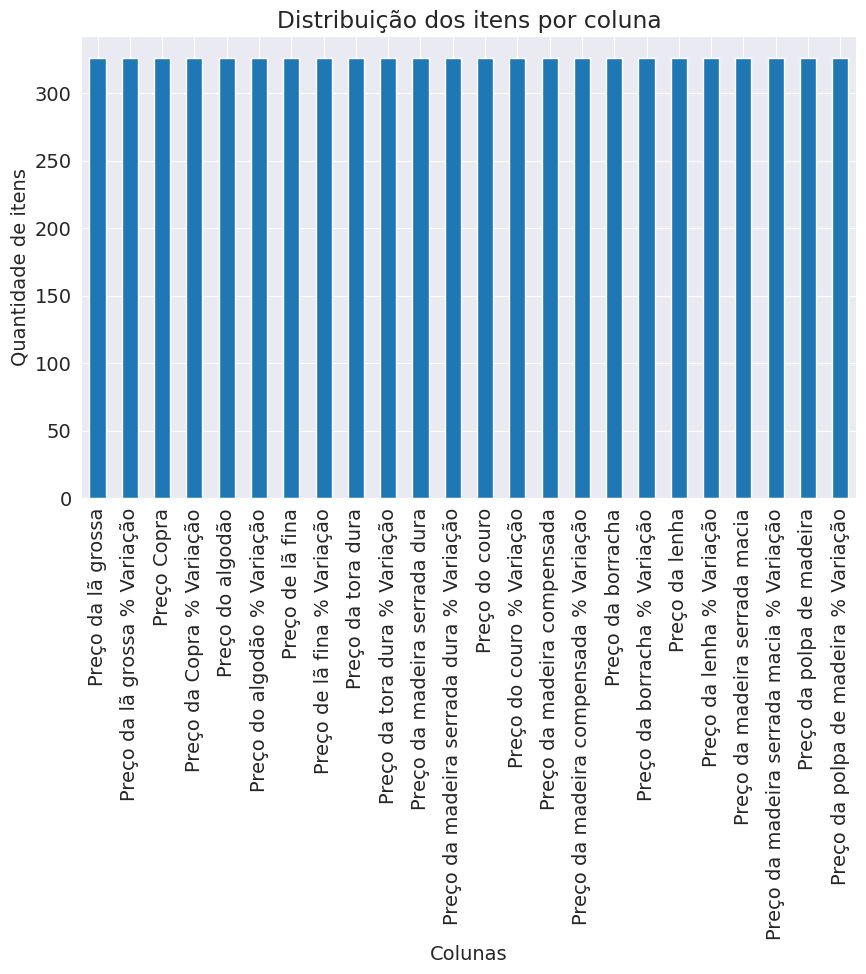

In [13]:
#gráfico de dados simples que mostra a contagem de itens de todas as colunas
plt.figure(figsize=(10, 6))
materiaPrima.count().plot(kind='bar')
plt.title('Distribuição dos itens por coluna')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de itens')

O gráfico de barras mostra que temos a mesma quantidade de itens para cada coluna (Preço da lã grossa, Preço da lã grossa % Variação, Preço Copra, Preço da Copra % Variação, Preço do algodão, Preço do algodão % Variação,
Preço de lã fina, Preço de lã fina % Variação, Preço da tora dura, Preço da tora dura % Variação, Preço da madeira serrada dura, Preço da madeira serrada dura % Variação, Preço do couro, Preço do couro % Variação,
Preço da madeira compensada, Preço da madeira compensada % Variação, Preço da borracha, Preço da borracha % Variação, Preço da lenha,  Preço da lenha % Variação, Preço da madeira serrada macia,
Preço da madeira serrada macia % Variação, Preço da polpa de madeira, Preço da polpa de madeira % Variação) possui 326 itens, confirmando que o dataset é balanceado em termos de itens por coluna.

<h1><b> Estatísticas Descritivas </b></h1>

In [14]:
# estatísticas descritivas básicas do dataset
materiaPrima.describe()

,Preço da lã grossa,Preço da lã grossa % Variação,Preço Copra,Preço da Copra % Variação,Preço do algodão,Preço do algodão % Variação,Preço de lã fina,Preço de lã fina % Variação,Preço da tora dura,Preço da tora dura % Variação,...,Preço da madeira compensada,Preço da madeira compensada % Variação,Preço da borracha,Preço da borracha % Variação,Preço da lenha,Preço da lenha % Variação,Preço da madeira serrada macia,Preço da madeira serrada macia % Variação,Preço da polpa de madeira,Preço da polpa de madeira % Variação
count,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,...,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000
mean,626.775429,3.845307,530.047761,5.562362,1.620736,3.999663,849.440092,4.803497,249.253620,3.257914,...,510.027178,2.268466,1.663282,5.499755,164.662025,5.442454,291.283497,4.979663,678.212362,2.800000
std,299.992828,3.628820,264.001641,5.091321,0.533457,3.930971,285.248110,4.698225,68.553994,3.423842,...,93.188458,2.659446,1.068344,5.185055,25.519555,4.768734,33.929470,5.773700,158.315029,2.890238
min,247.090000,0.000000,182.000000,0.000000,0.820000,0.000000,417.470000,0.000000,133.280000,0.010000,...,335.250000,0.000000,0.490000,0.000000,119.350000,0.000000,183.610000,0.000000,384.000000,0.000000
25%,368.490000,1.300000,371.000000,1.895000,1.272500,1.377500,646.257500,1.557500,195.275000,1.190000,...,434.727500,0.402500,0.842500,1.617500,146.117500,2.152500,277.717500,1.905000,544.632500,0.662500
50%,526.890000,2.910000,449.500000,4.350000,1.540000,2.840000,747.555000,3.470000,247.550000,2.335000,...,512.495000,1.470000,1.335000,3.910000,160.430000,4.230000,294.975000,3.695000,662.160000,2.000000
75%,848.795000,5.157500,657.125000,7.775000,1.830000,5.407500,1016.352500,6.362500,287.025000,4.285000,...,582.035000,3.147500,2.157500,7.397500,180.345000,7.457500,310.887500,6.122500,832.245000,4.107500
max,1391.470000,22.250000,1503.000000,31.820000,5.060000,23.640000,1865.440000,32.840000,520.810000,34.190000,...,751.810000,19.500000,6.260000,32.160000,259.970000,33.210000,372.600000,65.240000,966.490000,21.570000


In [15]:
# média dos atributos numéricos do dataset
materiaPrima.describe().loc['mean']

,mean
Preço da lã grossa,626.775429
Preço da lã grossa % Variação,3.845307
Preço Copra,530.047761
Preço da Copra % Variação,5.562362
Preço do algodão,1.620736
Preço do algodão % Variação,3.999663
Preço de lã fina,849.440092
Preço de lã fina % Variação,4.803497
Preço da tora dura,249.253620
Preço da tora dura % Variação,3.257914


Text(0, 0.5, 'Média')

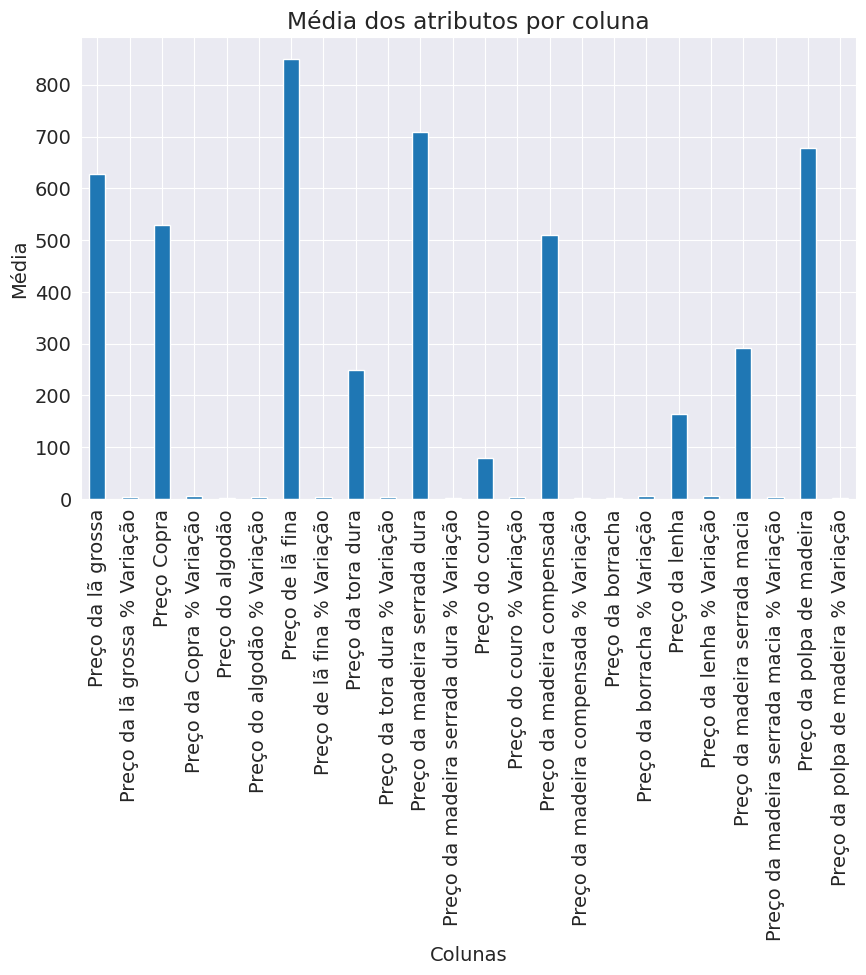

In [16]:
#Gráfico que representa a média dos atributos numéricos
plt.figure(figsize=(10, 6))
materiaPrima.describe().loc['mean'].plot(kind='bar')
plt.title('Média dos atributos por coluna')
plt.xlabel('Colunas')
plt.ylabel('Média')

Podemos observar que o preço médio da lã grossa, copra, lã fina, madeira serrada dura, madeira compensada e polpa de madeira, possuem uma variação muito maior que as demais.


In [17]:
# desvio padrão dos atributos numéricos do dataset
materiaPrima.describe().loc['std']

,std
Preço da lã grossa,299.992828
Preço da lã grossa % Variação,3.628820
Preço Copra,264.001641
Preço da Copra % Variação,5.091321
Preço do algodão,0.533457
Preço do algodão % Variação,3.930971
Preço de lã fina,285.248110
Preço de lã fina % Variação,4.698225
Preço da tora dura,68.553994
Preço da tora dura % Variação,3.423842


Text(0, 0.5, 'Desvio padrão')

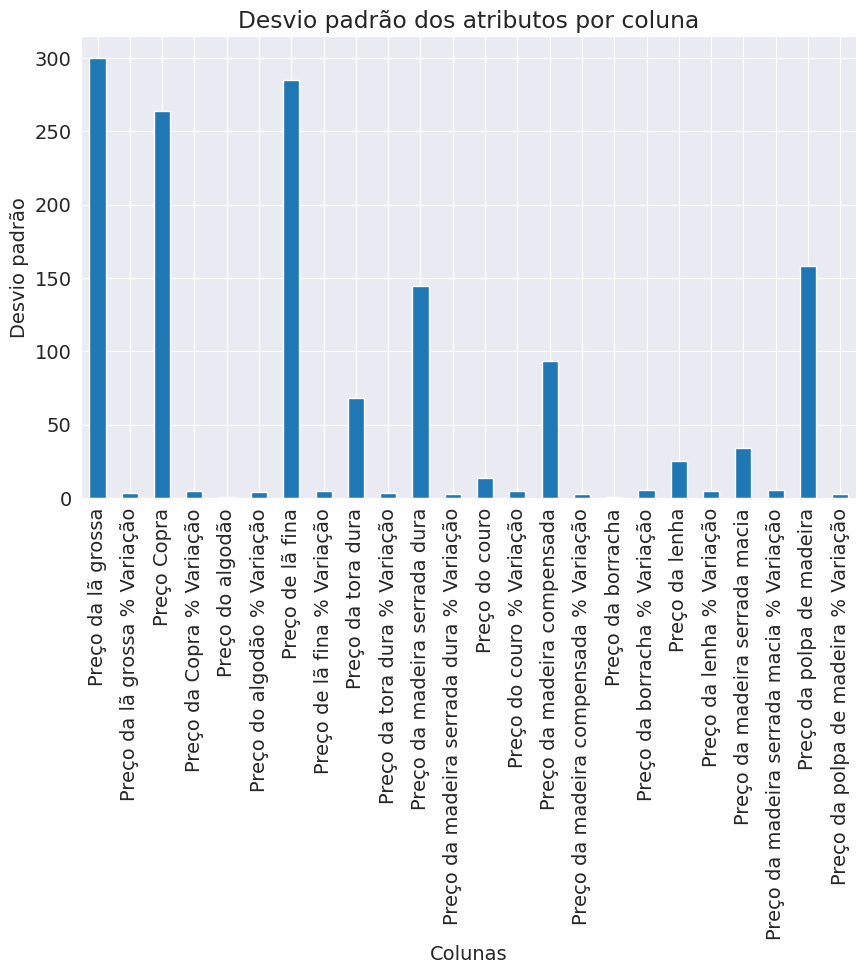

In [18]:
#Gráfico que representa o desvio padrão dos atributos numéricos
plt.figure(figsize=(10, 6))
materiaPrima.describe().loc['std'].plot(kind='bar')
plt.title('Desvio padrão dos atributos por coluna')
plt.xlabel('Colunas')
plt.ylabel('Desvio padrão')

Podemos observar que o desvio padrão da lã grossa, copra, lã fina, possuem uma variação muito maior que as demais, deixando eles mais dispersos e mais distantes da média

<h1><b> Normalização / Padronização</b></h1>

Decidi não utilizar nenhuma das soluções por entender que que os dados estão dentro de uma realidade muito boa para uma boa análise.

<h1><b> Mapa de calor </b><h1>

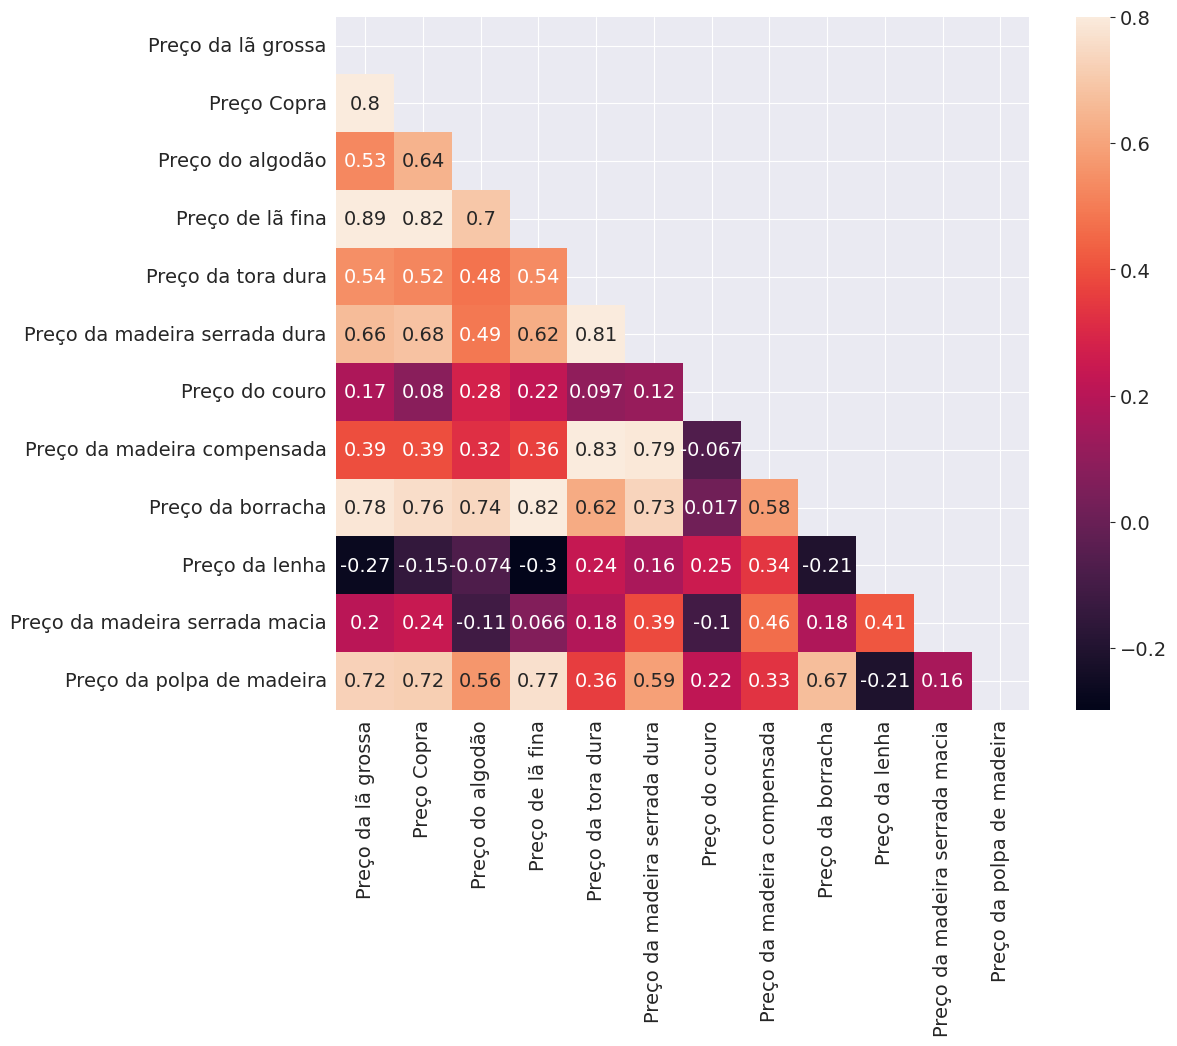

In [19]:
fig = plt.figure(figsize = (12, 9))
#lista de matérias-primas
raw_data=['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira']

#obtendo a matriz de correlação
corrmat = materiaPrima[raw_data].corr()

#mascarando a parte superior do triângulo, já que a matriz é simétrica (repetitiva)
mask = np.triu(np.ones_like(corrmat, dtype=bool))
sns.heatmap(corrmat, vmax = .8,mask=mask, square = True, annot = True)
plt.show()

O mapa de calor mostra a correlação entre as matérias-primas maior o valor correlacionado maior chance de serem duas matérias-primas relacionadas, mas não necessariamente

As colunas com maior correlação são: 'Preço da lã grossa' e 'Preço do algodão' com correlação de 0.53


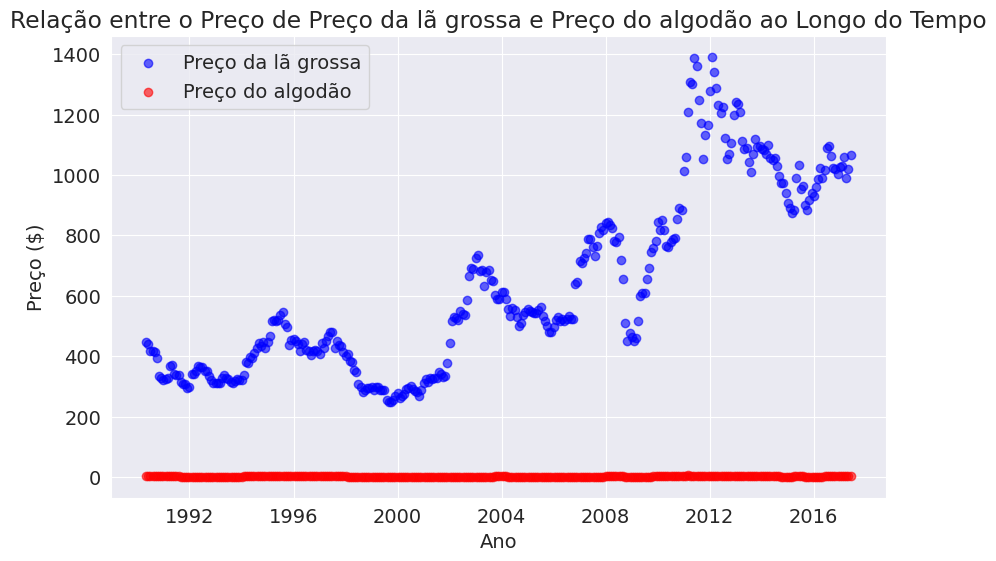

In [20]:
# Escolhendo duas colunas com alta correlação
# Lista de matérias-primas para análise de preço
raw_data = ['Preço da lã grossa',  'Preço do algodão']

# Obtendo a matriz de correlação apenas para as colunas de preço
corrmat = materiaPrima[raw_data].corr()

# Encontrando o par de colunas com maior correlação absoluta (excluindo a diagonal)
# Inicializa as variáveis para armazenar a maior correlação e os nomes das colunas
max_corr = 0
coluna1 = ''
coluna2 = ''

# Itera sobre a matriz de correlação
for i in range(len(corrmat.columns)):
    for j in range(i + 1, len(corrmat.columns)): # Itera apenas sobre o triângulo superior
        correlation = abs(corrmat.iloc[i, j])
        if correlation > max_corr:
            max_corr = correlation
            coluna1 = corrmat.columns[i]
            coluna2 = corrmat.columns[j]

print(f"As colunas com maior correlação são: '{coluna1}' e '{coluna2}' com correlação de {max_corr:.2f}")

# Plotando o gráfico de dispersão para as colunas com maior correlação
plt.figure(figsize=(10, 6))

plt.scatter(materiaPrima.index, materiaPrima[coluna1], label=coluna1, color='blue', alpha=0.6)
plt.scatter(materiaPrima.index, materiaPrima[coluna2], label=coluna2, color='red', alpha=0.6)

plt.title(f'Relação entre o Preço de {coluna1} e {coluna2} ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico de dispersão mostra a relação entre os preços das duas matérias-primas escolhidas ao longo do tempo. Cada ponto no gráfico representa um ponto de dados (um mês específico) com o preço da coluna1 no eixo x e o preço da coluna2 no eixo y. Mostrando o preço do algodão estável através dos anos, a alta variação do preço da lã grossa através dos anos e a baixa correlação entre os mesmo.

As colunas com maior correlação são: 'Preço da lã grossa' e 'Preço de lã fina' com correlação de 0.89


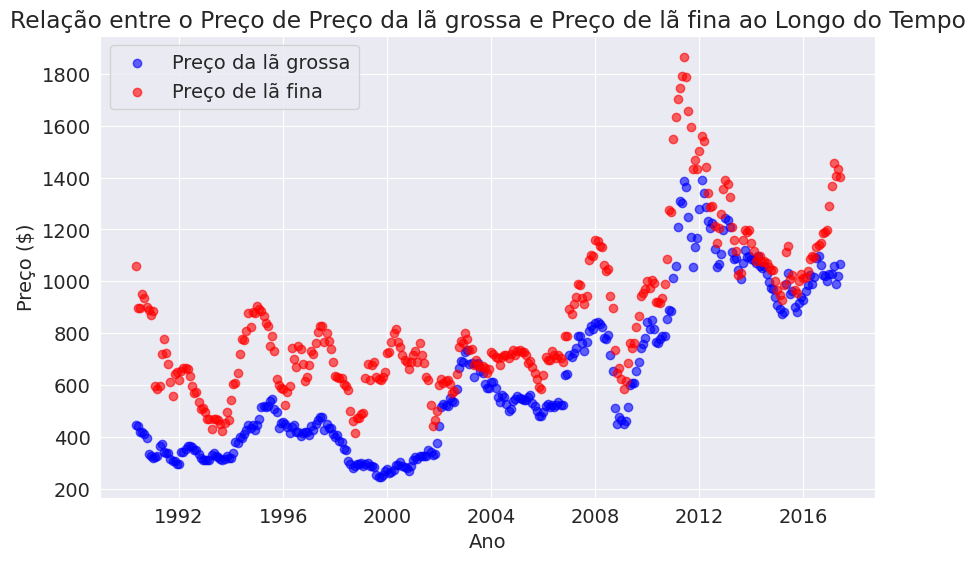

In [21]:
# Escolhendo duas colunas com alta correlação
# Lista de matérias-primas para análise de preço
raw_data = ['Preço da lã grossa',  'Preço de lã fina']

# Obtendo a matriz de correlação apenas para as colunas de preço
corrmat = materiaPrima[raw_data].corr()

# Encontrando o par de colunas com maior correlação absoluta (excluindo a diagonal)
# Inicializa as variáveis para armazenar a maior correlação e os nomes das colunas
max_corr = 0
coluna1 = ''
coluna2 = ''

# Itera sobre a matriz de correlação
for i in range(len(corrmat.columns)):
    for j in range(i + 1, len(corrmat.columns)): # Itera apenas sobre o triângulo superior
        correlation = abs(corrmat.iloc[i, j])
        if correlation > max_corr:
            max_corr = correlation
            coluna1 = corrmat.columns[i]
            coluna2 = corrmat.columns[j]

print(f"As colunas com maior correlação são: '{coluna1}' e '{coluna2}' com correlação de {max_corr:.2f}")

# Plotando o gráfico de dispersão para as colunas com maior correlação
plt.figure(figsize=(10, 6))

plt.scatter(materiaPrima.index, materiaPrima[coluna1], label=coluna1, color='blue', alpha=0.6)
plt.scatter(materiaPrima.index, materiaPrima[coluna2], label=coluna2, color='red', alpha=0.6)

plt.title(f'Relação entre o Preço de {coluna1} e {coluna2} ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico de dispersão mostra a relação entre os preços das duas matérias-primas escolhidas ao longo do tempo. Cada ponto no gráfico representa um ponto de dados (um mês específico) com o preço da coluna1 no eixo x e o preço da coluna2 no eixo y. Mostrando o preço da lã grossa e do preço da lã fina variando juntos através do tempo e trazendo uma alta correlação entre ambos.

##Preços e seus gráficos de % de mudança

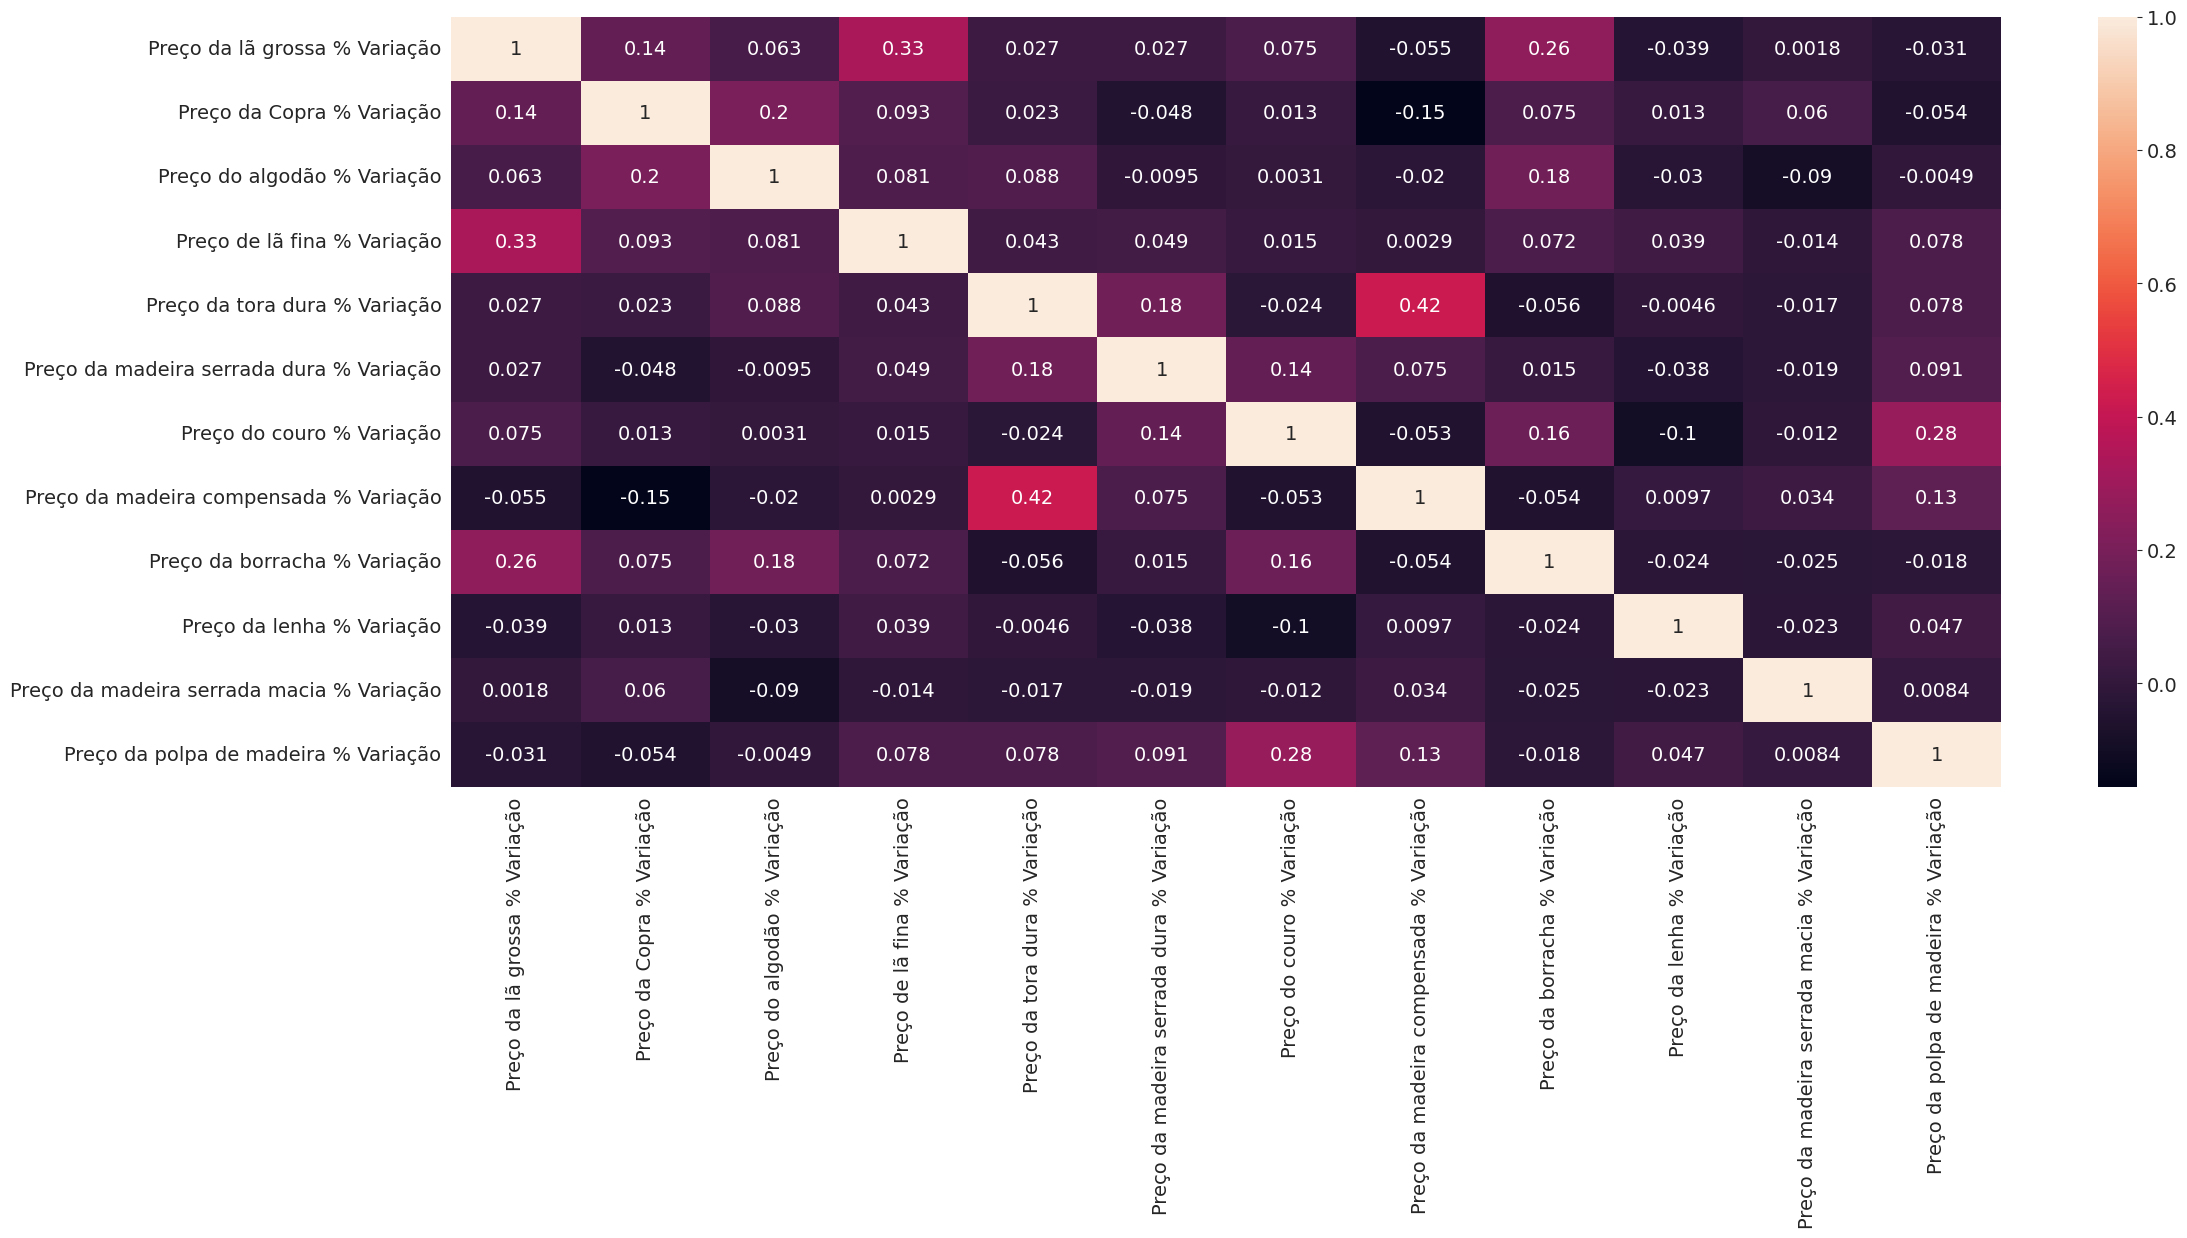

In [22]:
plt.figure(figsize=(25,10))
changelist=['Preço da lã grossa % Variação', 'Preço da Copra % Variação', 'Preço do algodão % Variação', 'Preço de lã fina % Variação',
'Preço da tora dura % Variação', 'Preço da madeira serrada dura % Variação', 'Preço do couro % Variação',
'Preço da madeira compensada % Variação', 'Preço da borracha % Variação', 'Preço da lenha % Variação', 'Preço da madeira serrada macia % Variação',
'Preço da polpa de madeira % Variação']
#gera uma matriz de correlação para todo o conjunto de dados
corrMatrix = materiaPrima[changelist].corr()
sns.heatmap(corrMatrix, annot=True)
plt.show()

A partir deste gráfico podemos dizer que quase não há relação entre a variação percentual dos preços das matérias-primas.

o valor negativo implica que duas variáveis ​​estão negativamente correlacionadas (um aumento, outro decréscimo);

Zero implica nenhuma relação;

Caso contrário, maior o valor maior a chance de relação;

<h1><b> Preços e suas Variações </b></h1>


Text(0.5, 0, 'Ano')

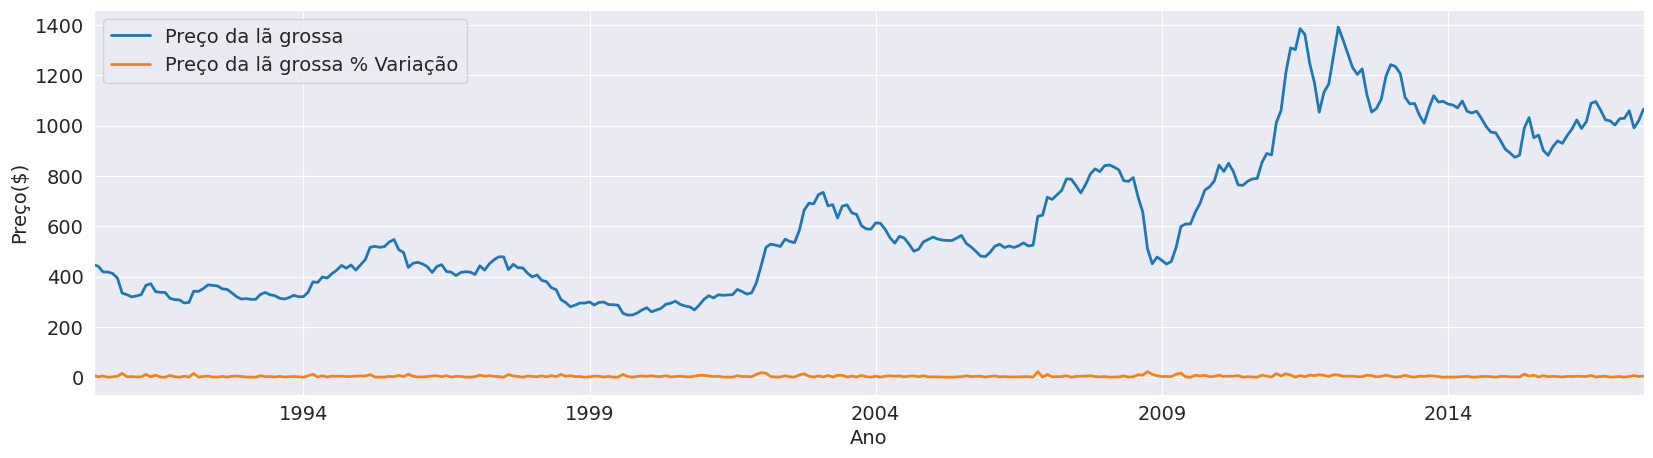

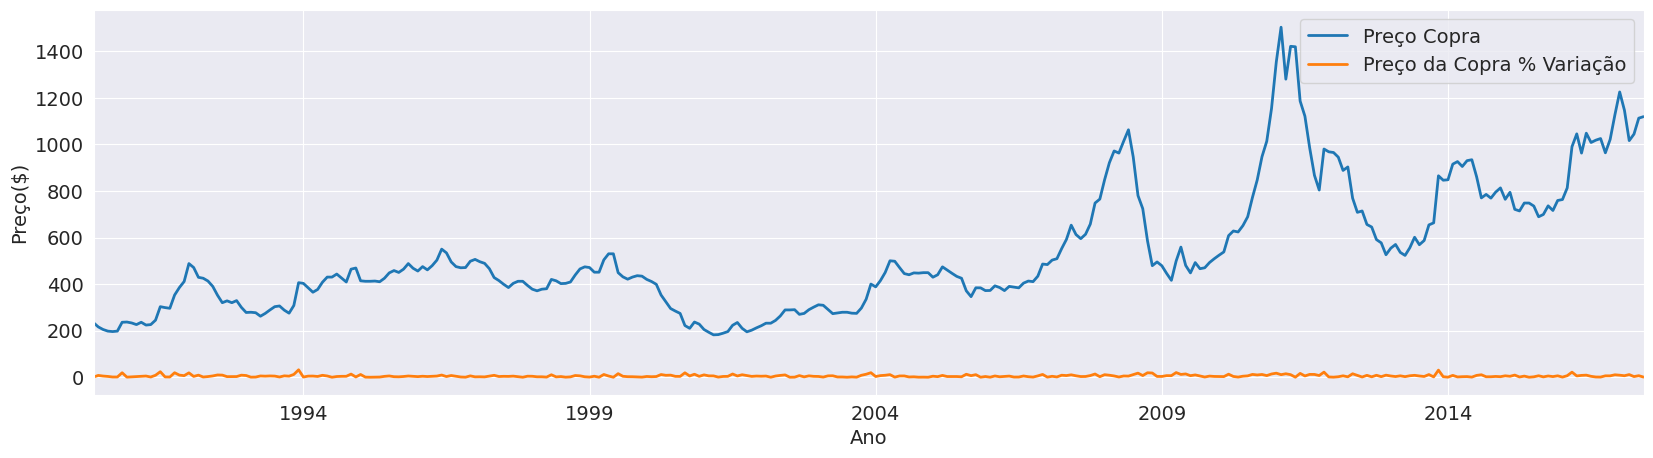

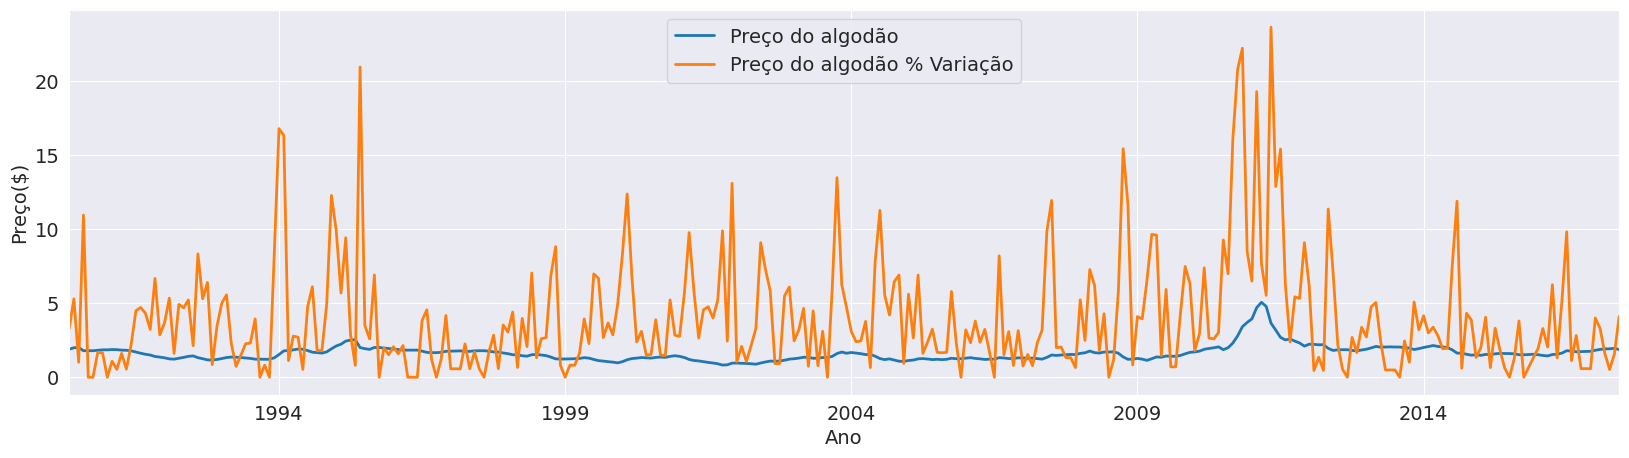

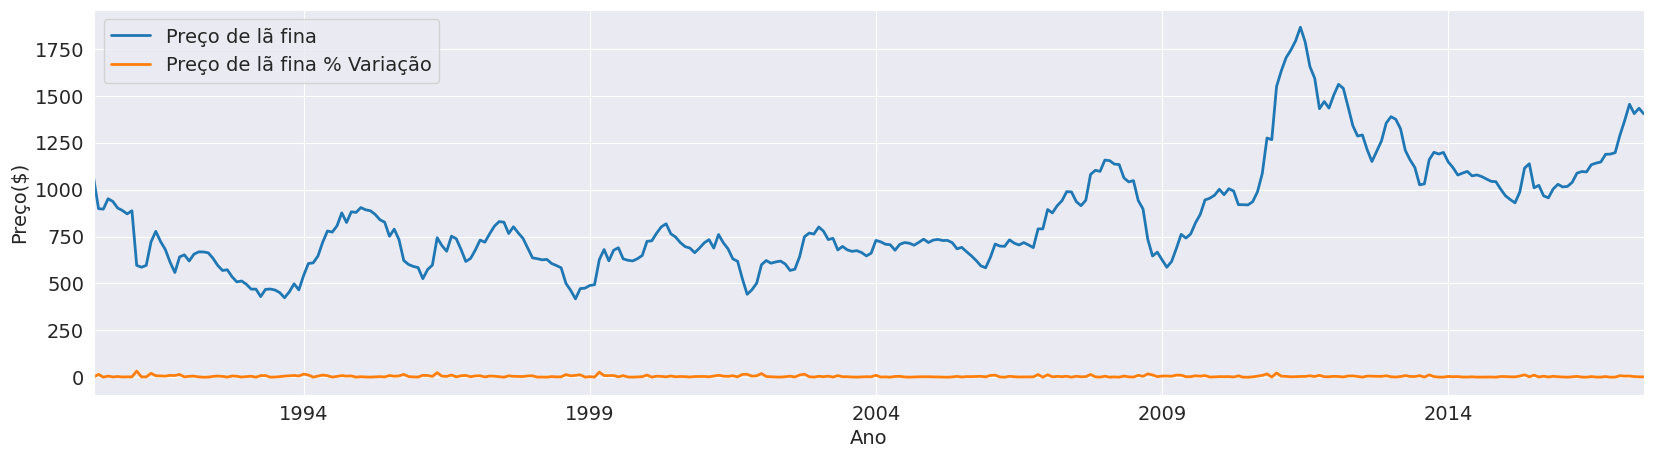

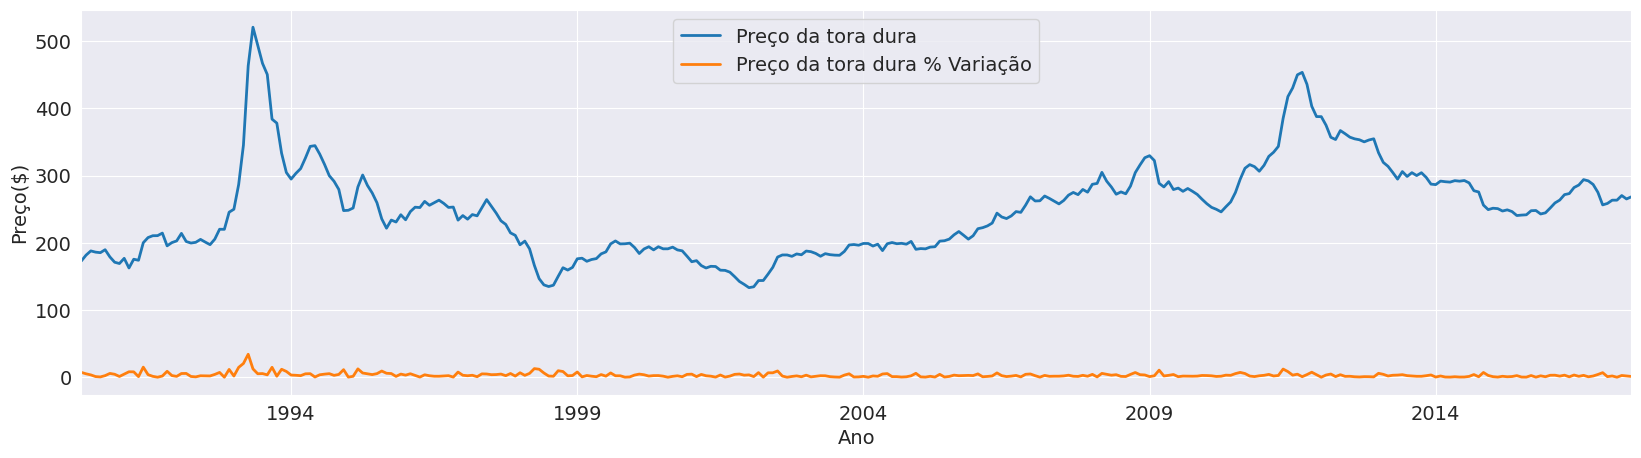

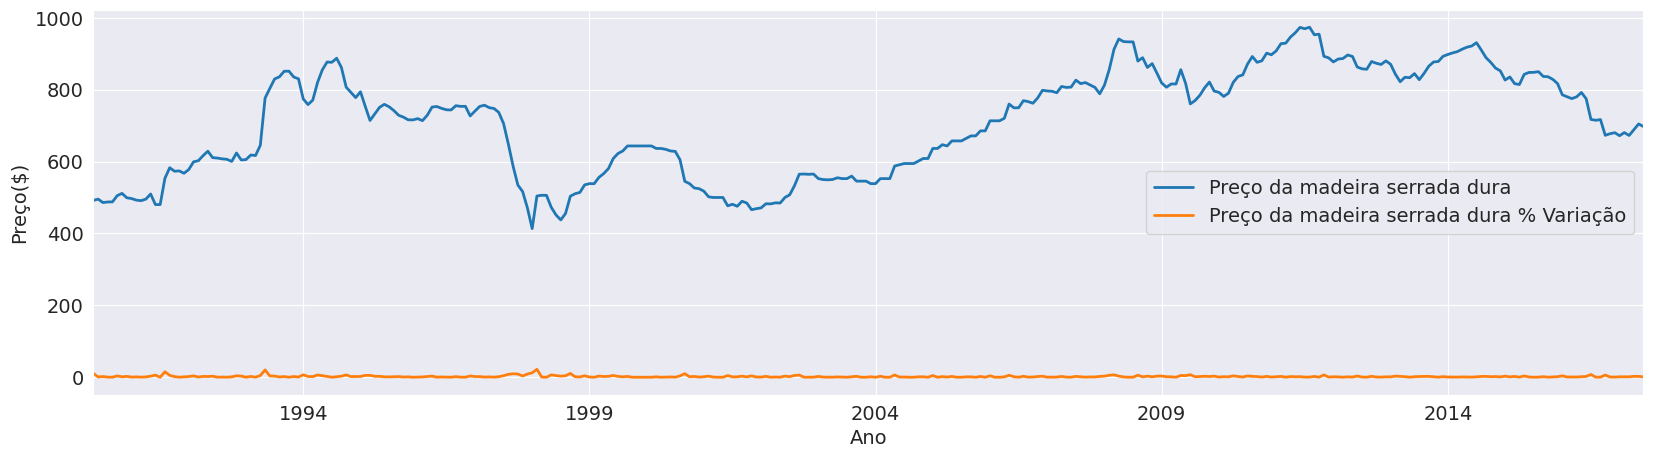

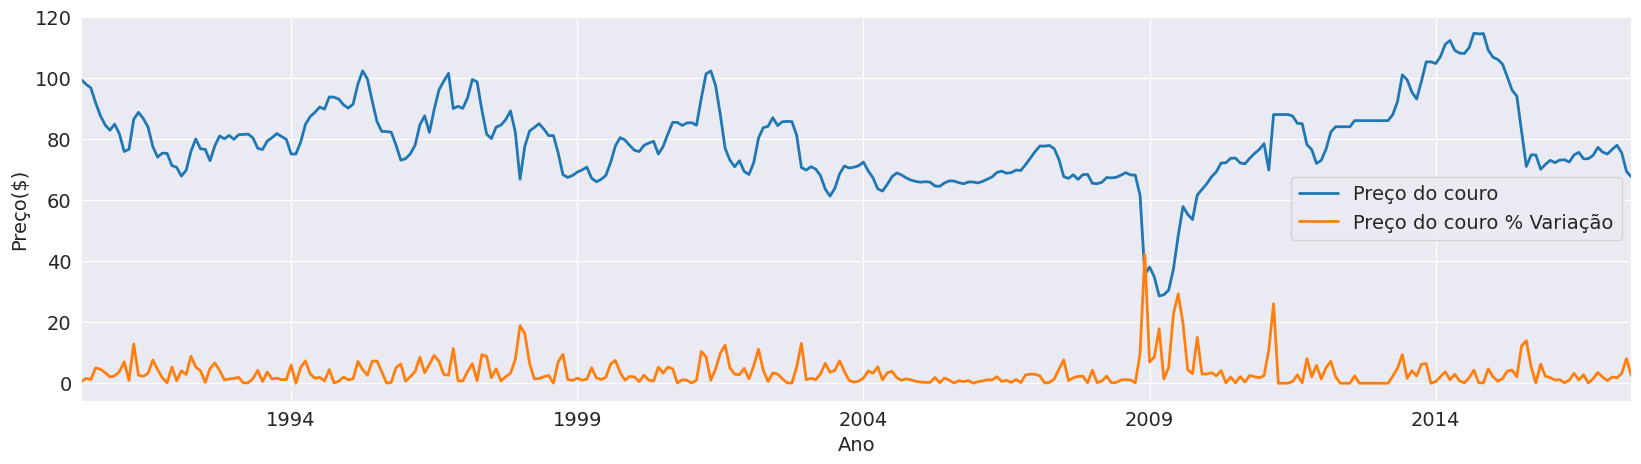

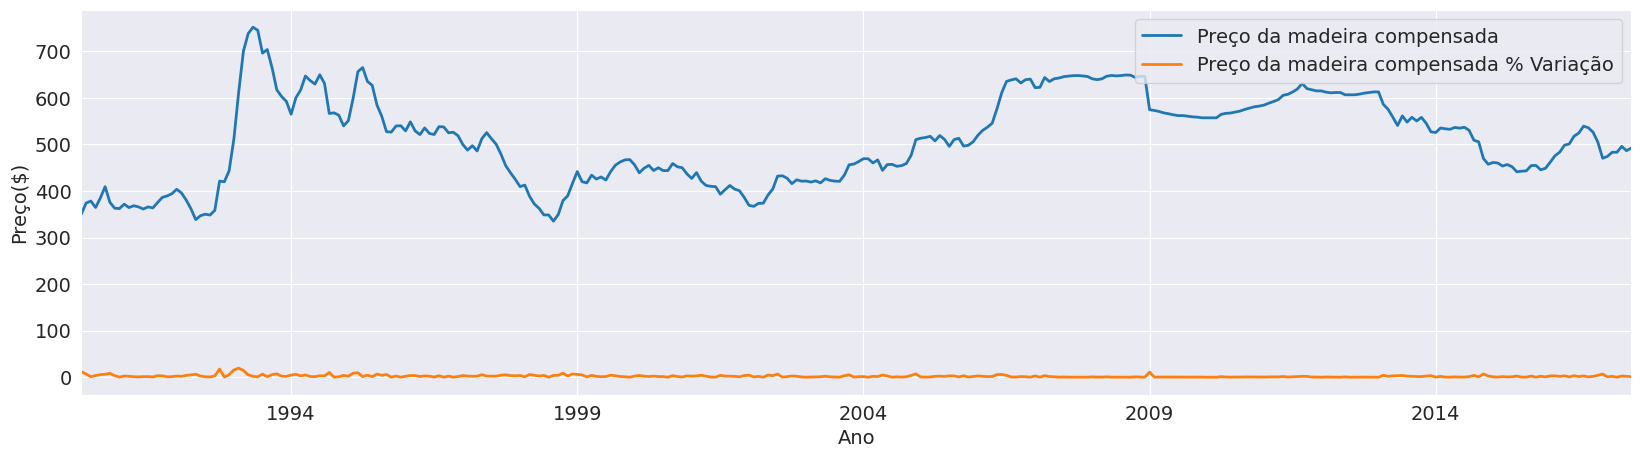

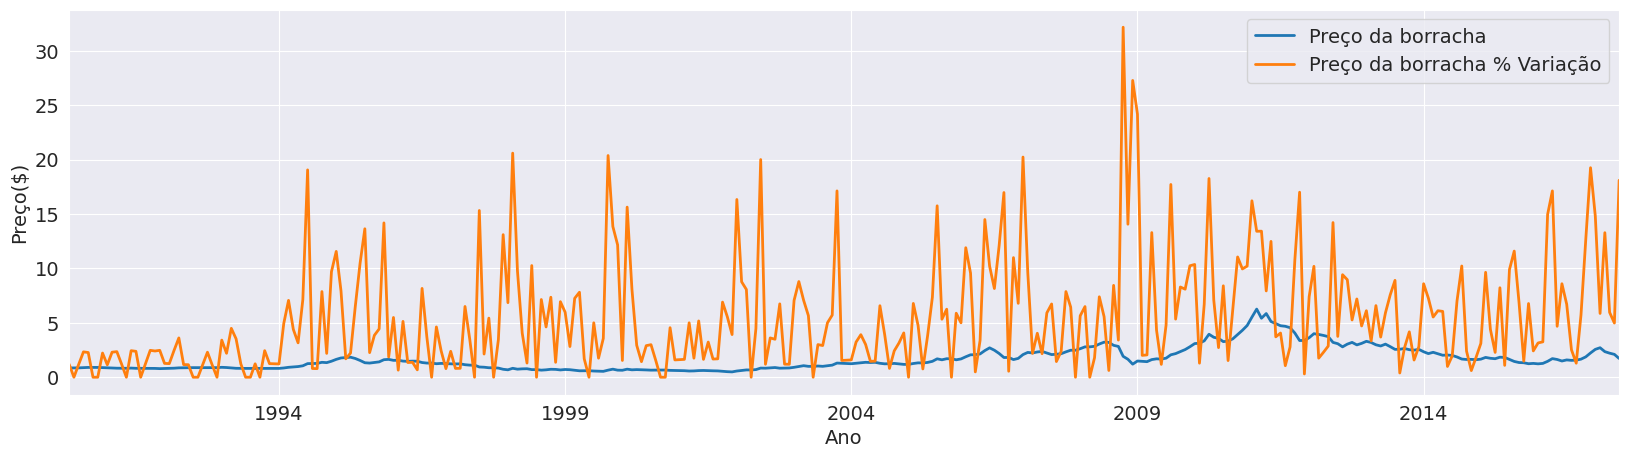

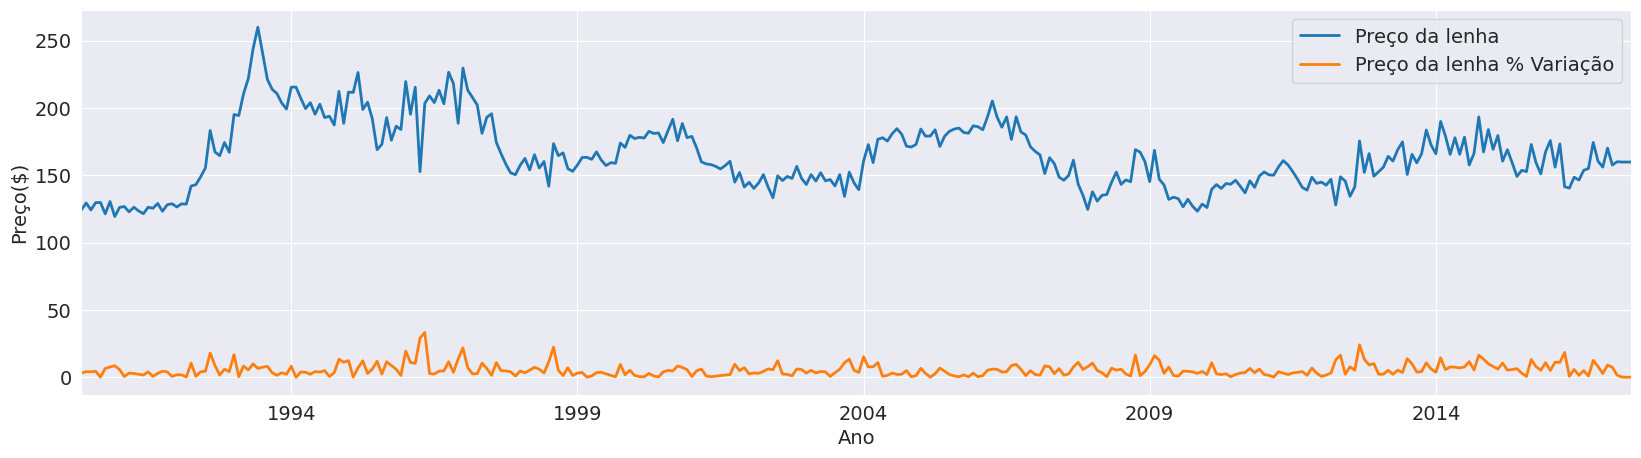

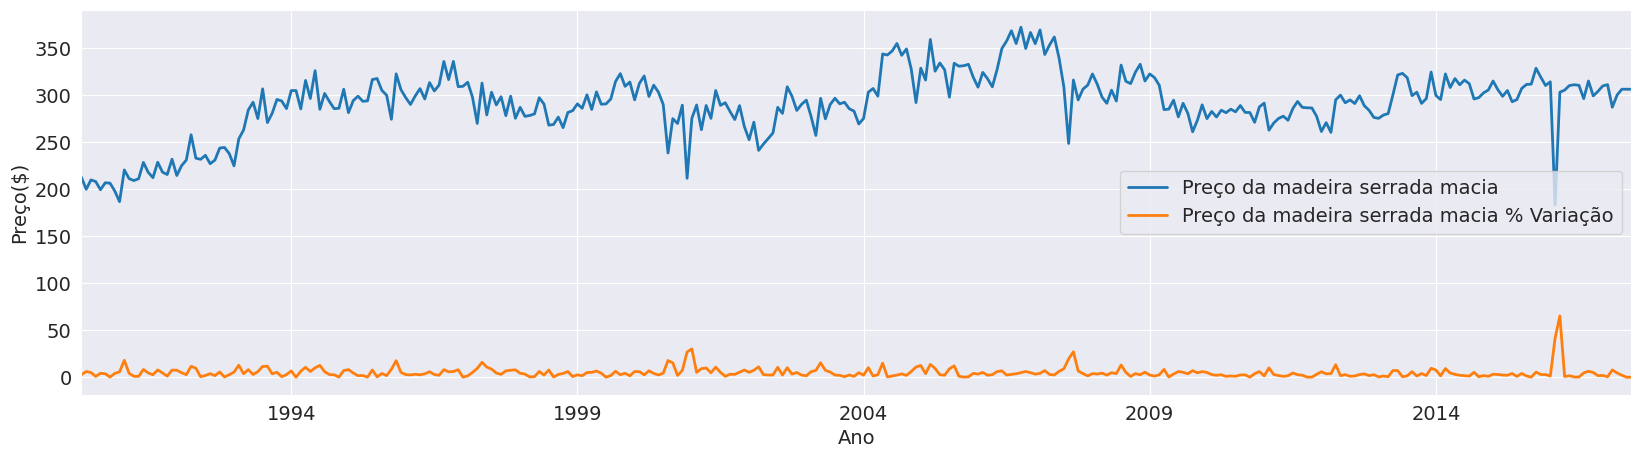

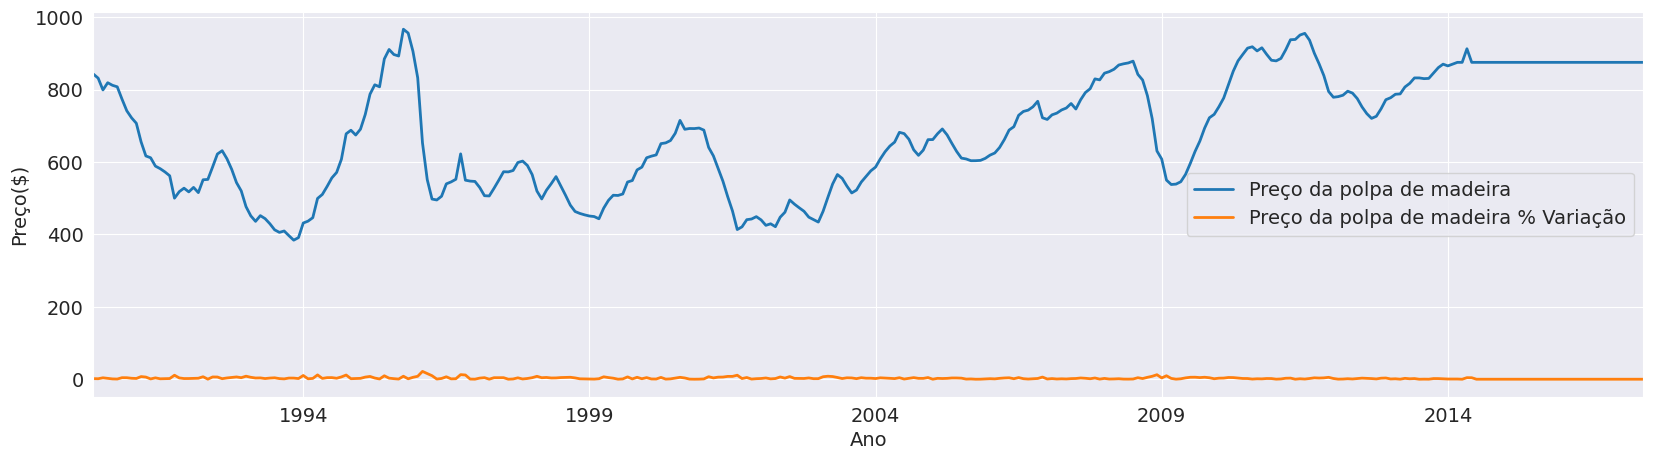

In [23]:
axes=materiaPrima[["Preço da lã grossa", "Preço da lã grossa % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço Copra", "Preço da Copra % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço do algodão", "Preço do algodão % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço de lã fina", "Preço de lã fina % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da tora dura", "Preço da tora dura % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da madeira serrada dura", "Preço da madeira serrada dura % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço do couro", "Preço do couro % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da madeira compensada", "Preço da madeira compensada % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da borracha", "Preço da borracha % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da lenha",  "Preço da lenha % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da madeira serrada macia", "Preço da madeira serrada macia % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')
axes=materiaPrima[["Preço da polpa de madeira", "Preço da polpa de madeira % Variação"]].plot(figsize=(20, 5), subplots=False, linewidth=2)
axes.set_ylabel('Preço($)')
axes.set_xlabel('Ano')

Esses gráficos mostram o preço e sua variação através dos anos.

Exemplo:

lã grossa - Preços diversificados com baixa variação


<h1><b> Respondendo as perguntas </b></h1>

##1) Descubra a variação normal do preço de cada matéria-prima

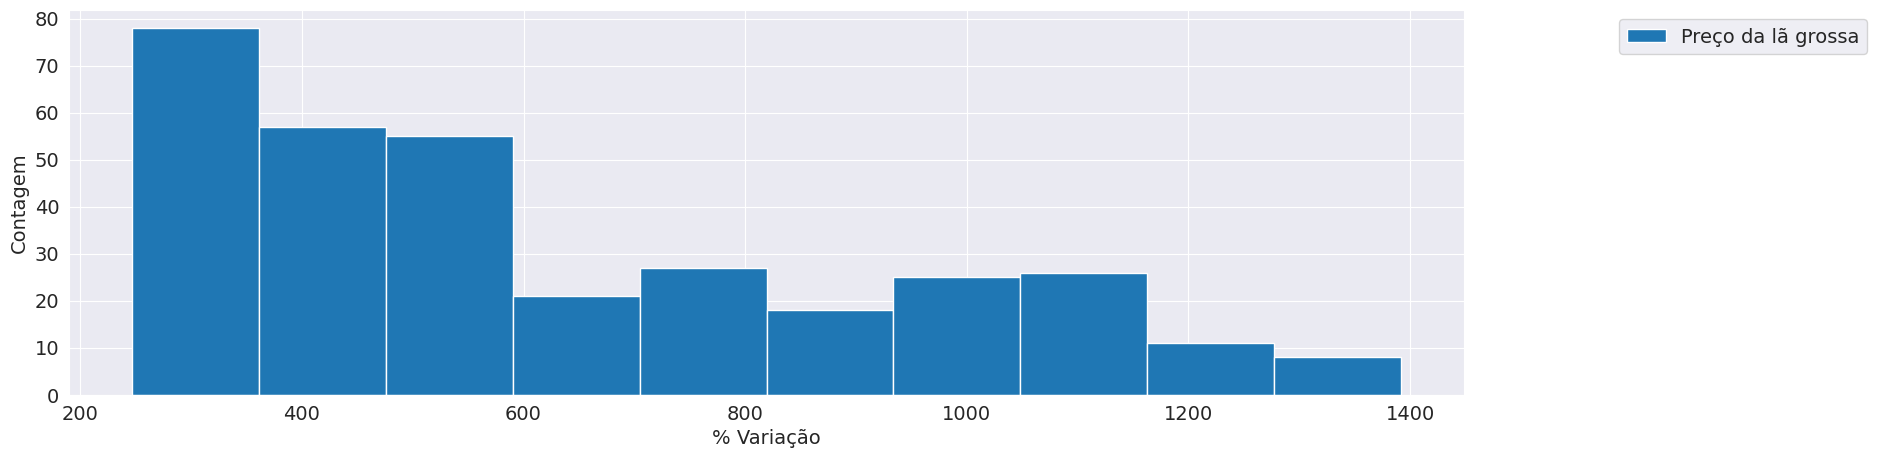

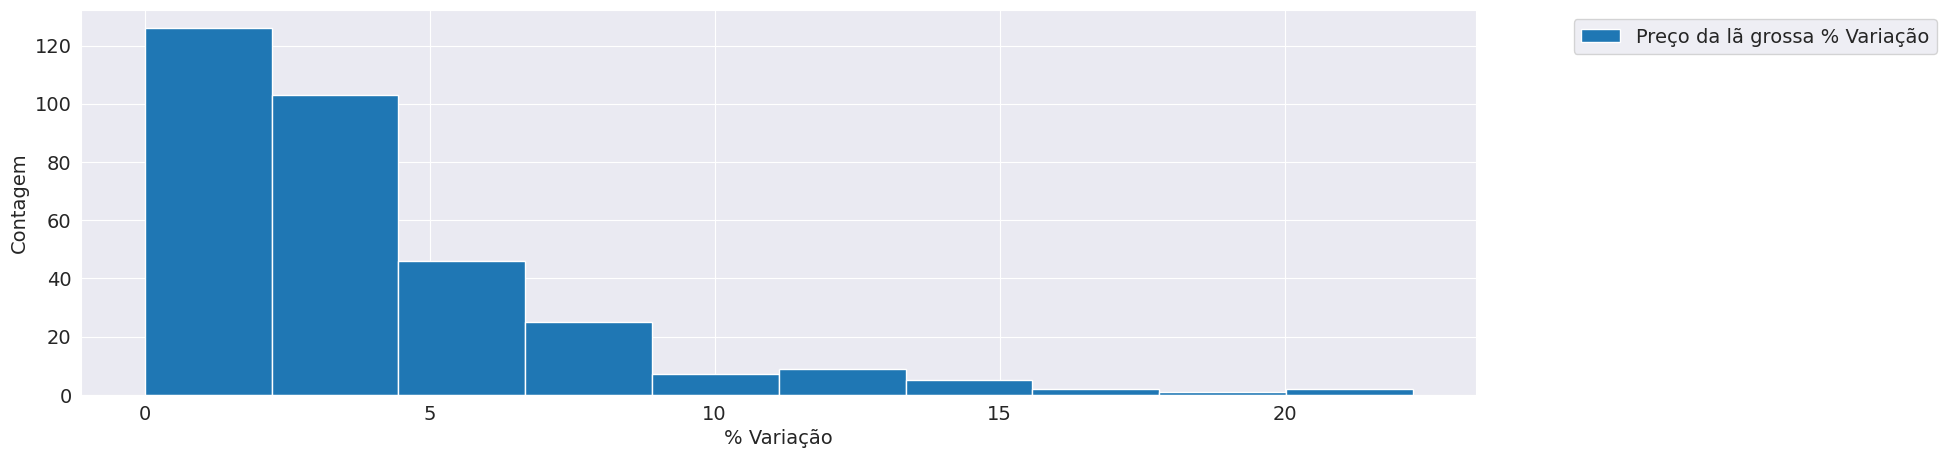

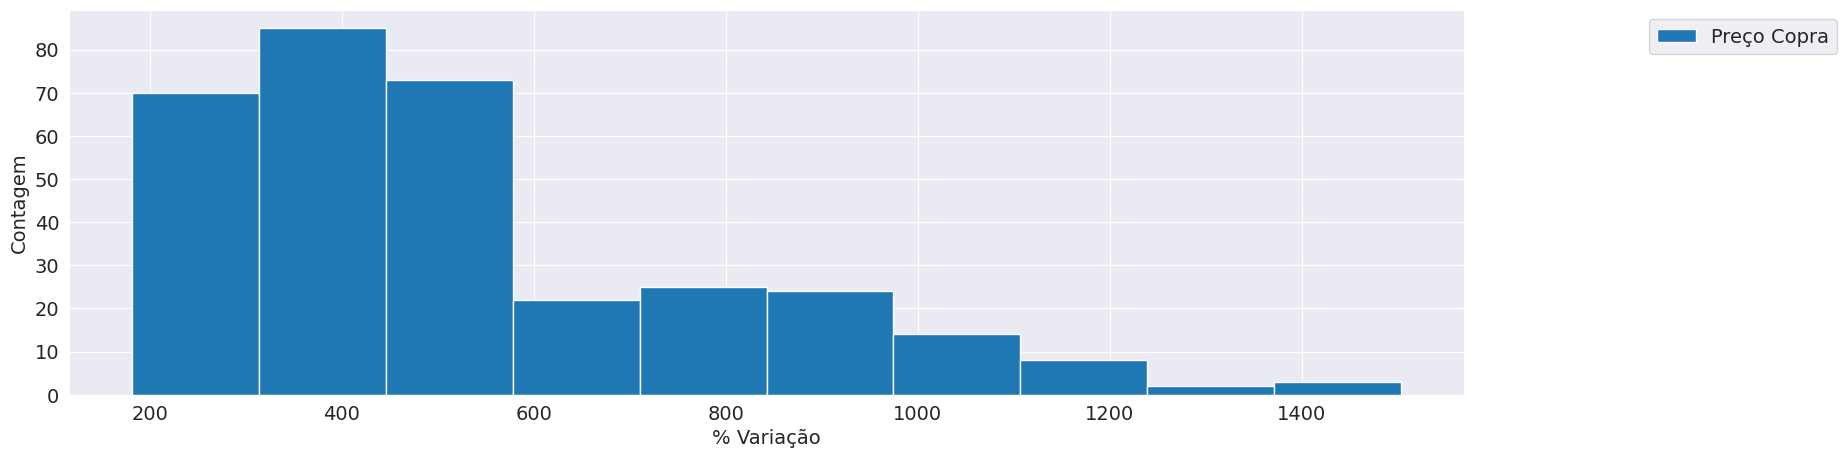

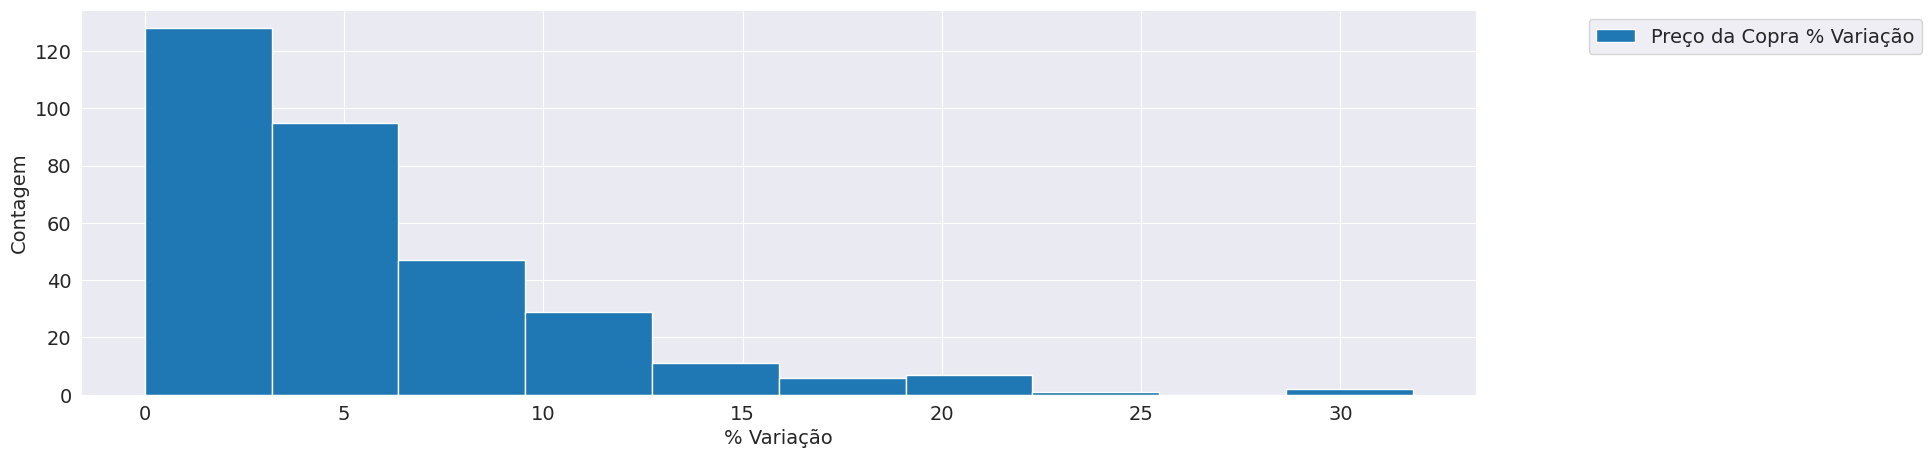

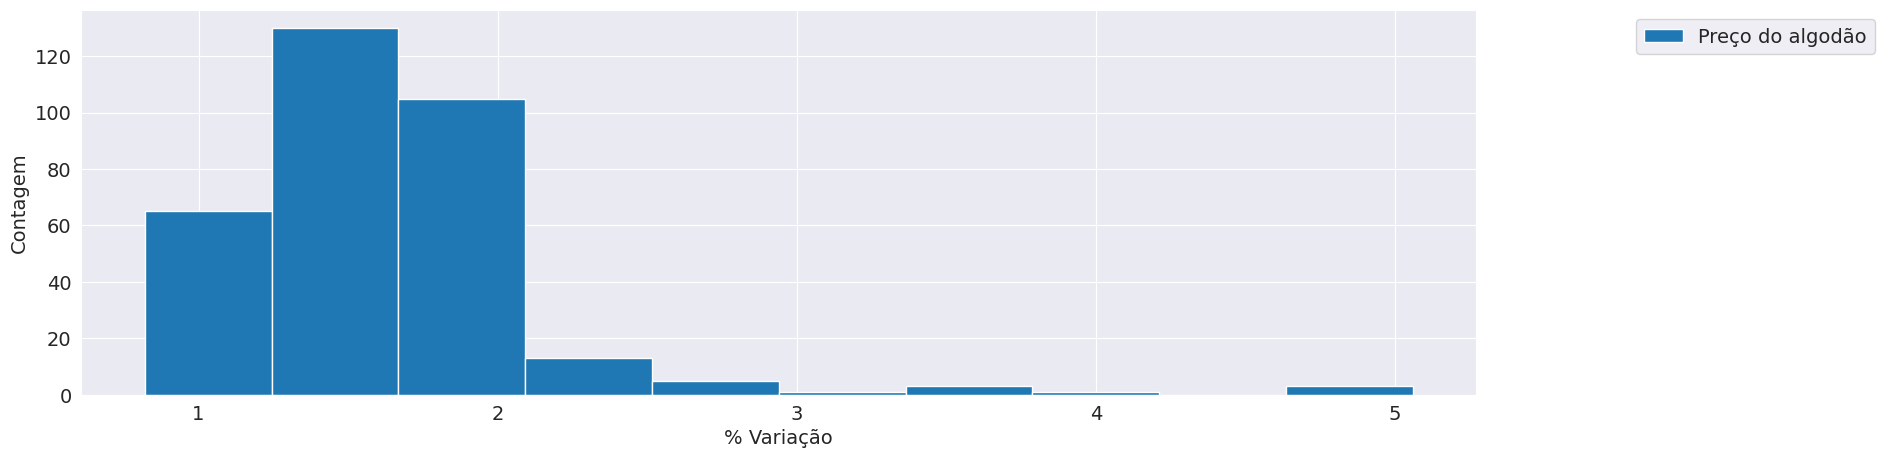

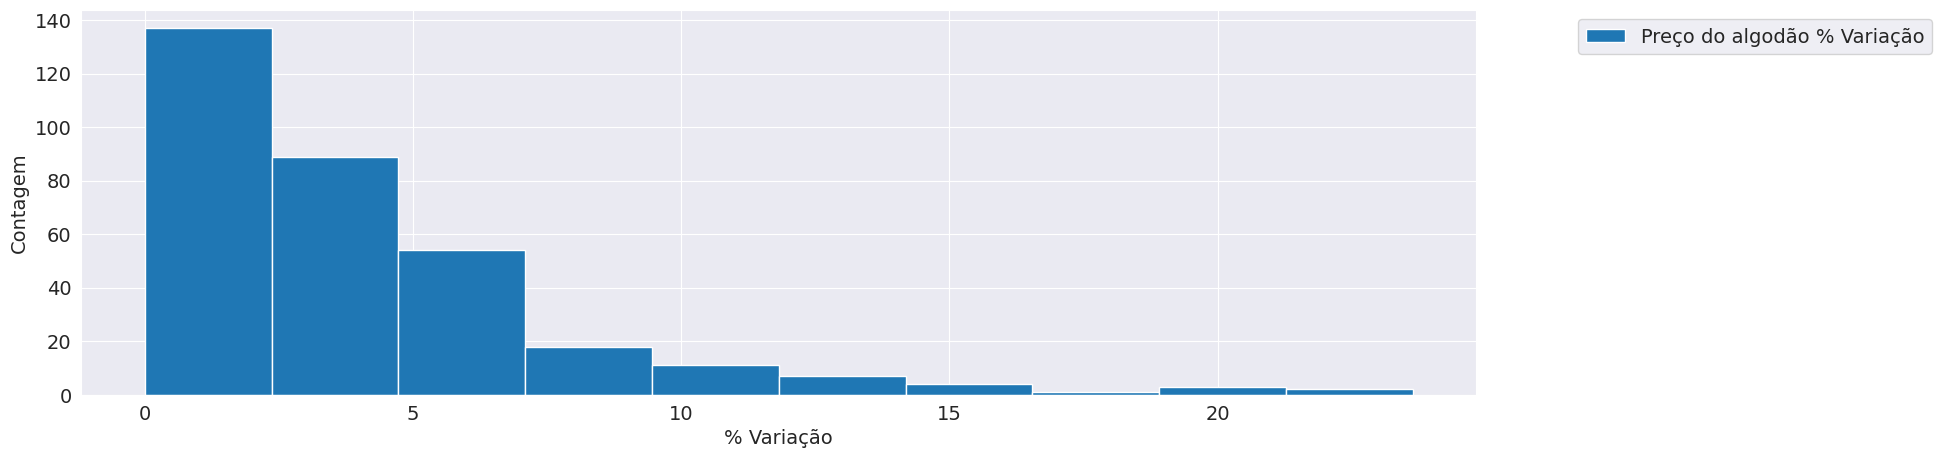

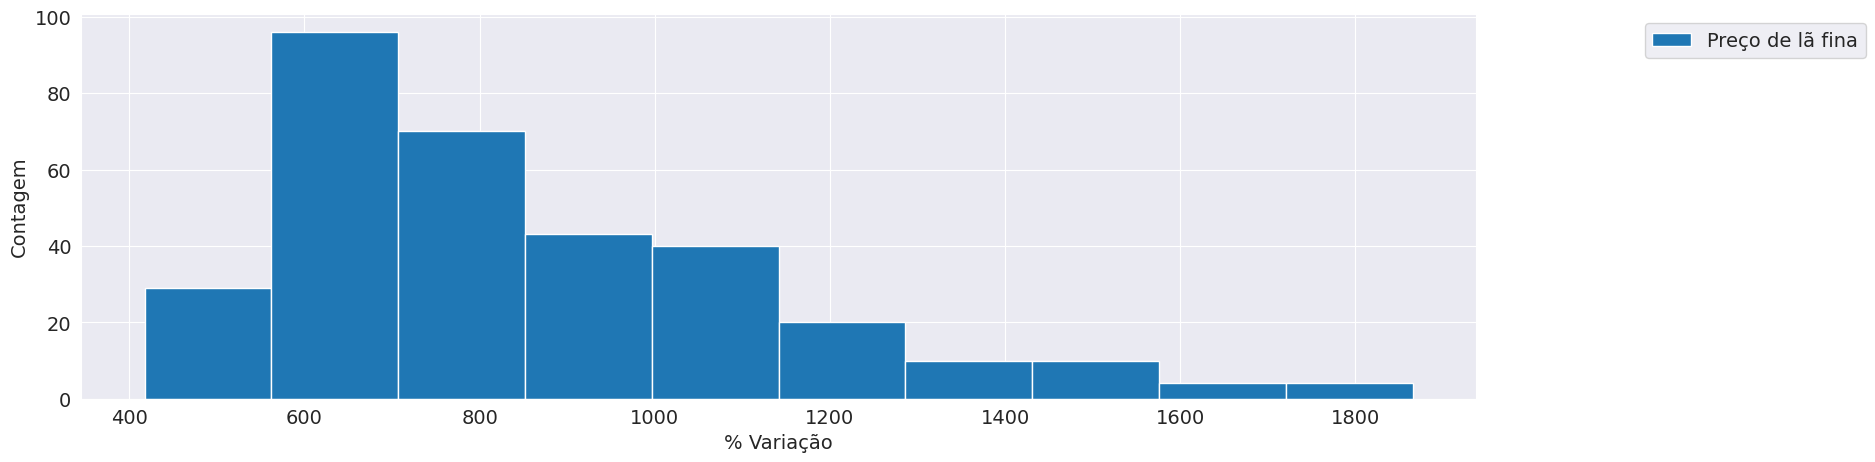

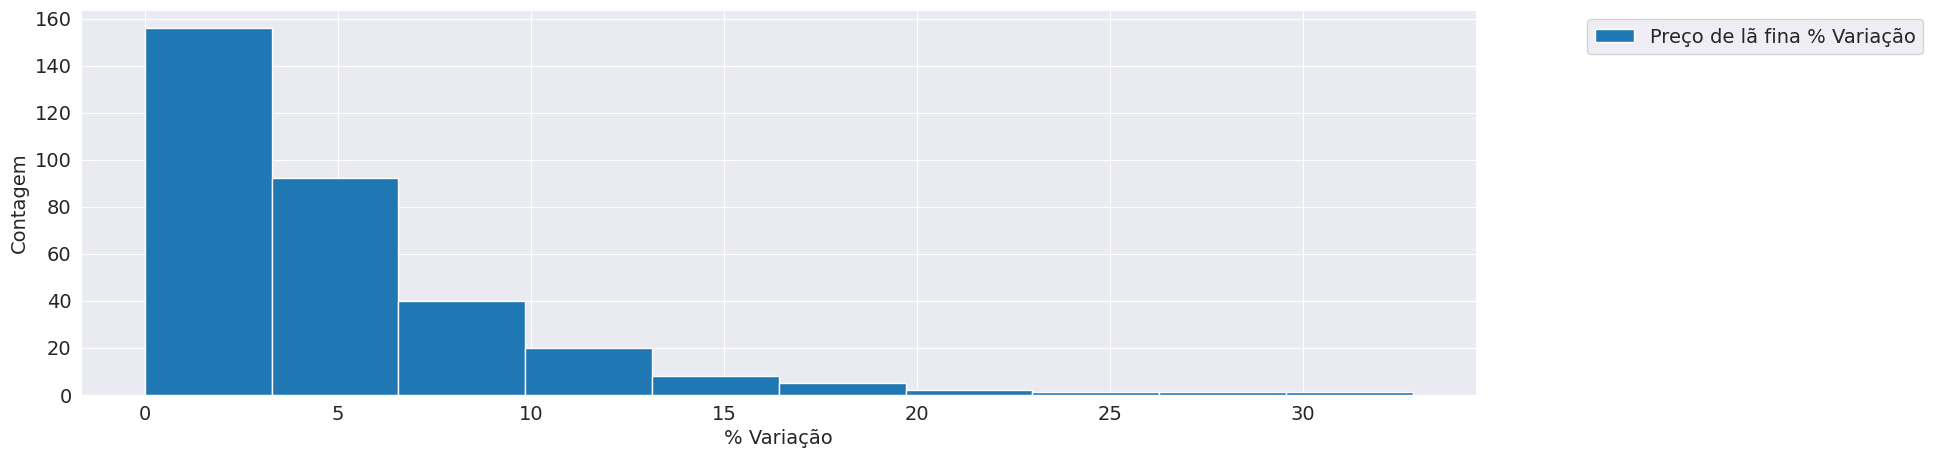

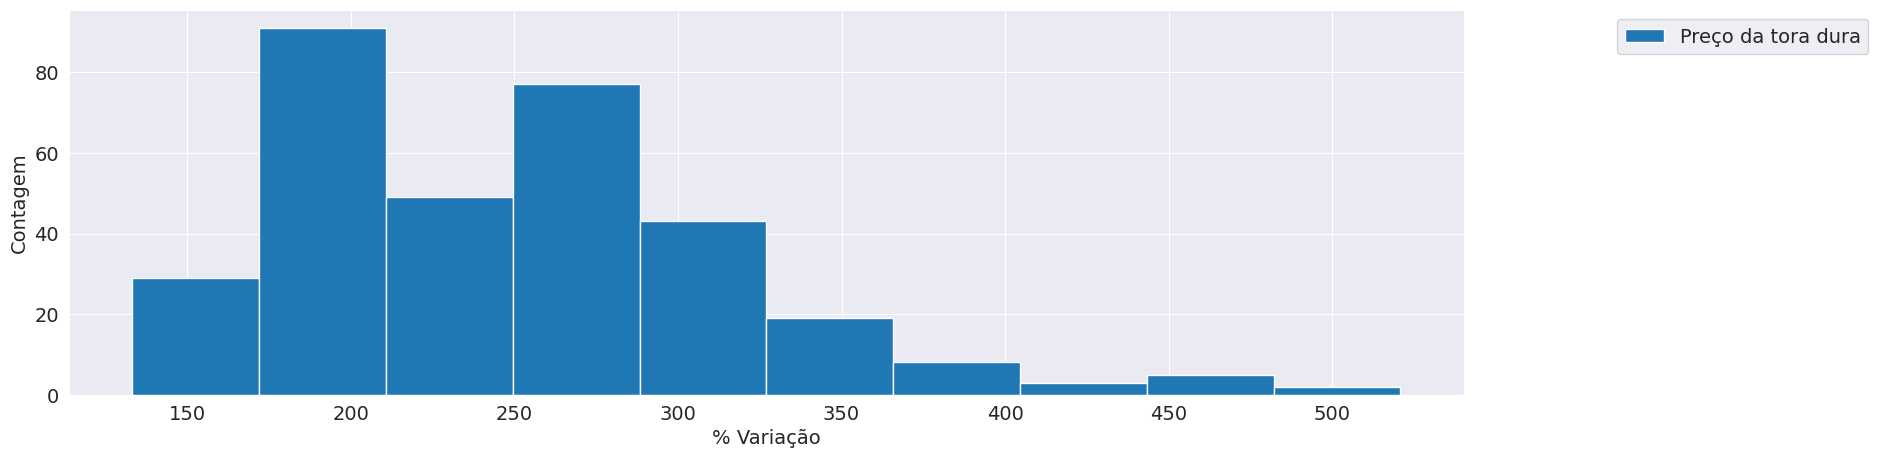

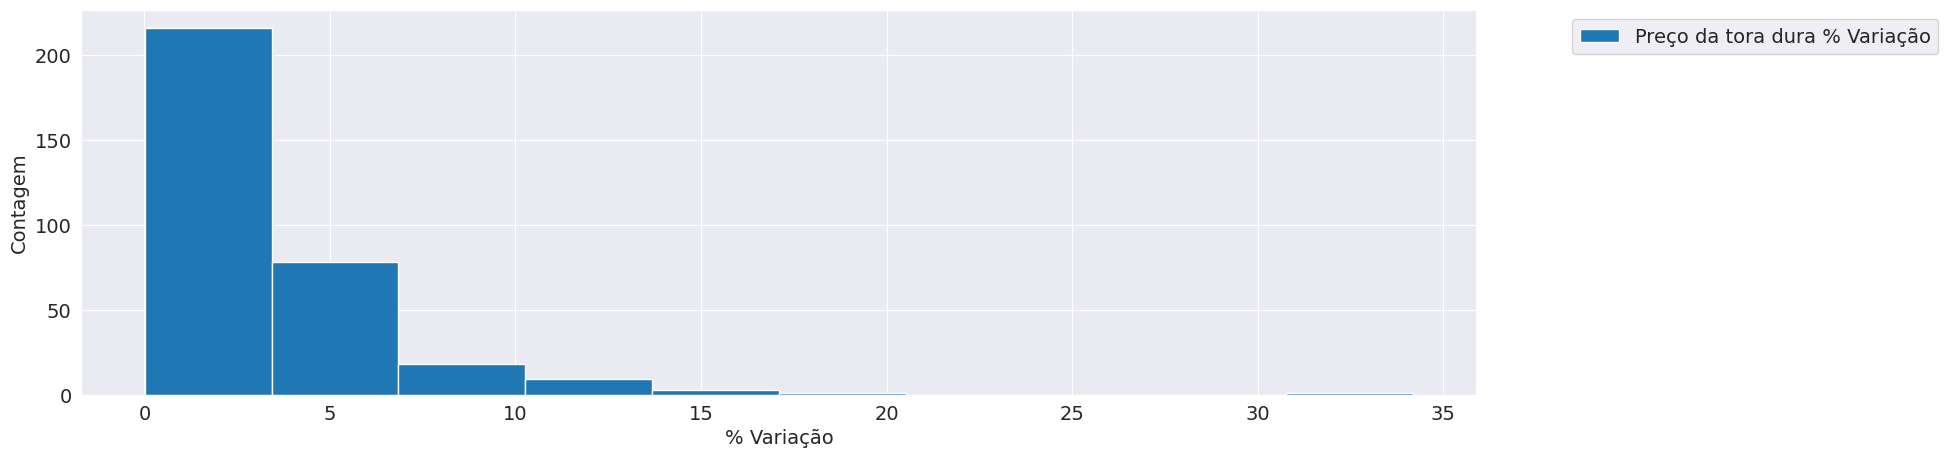

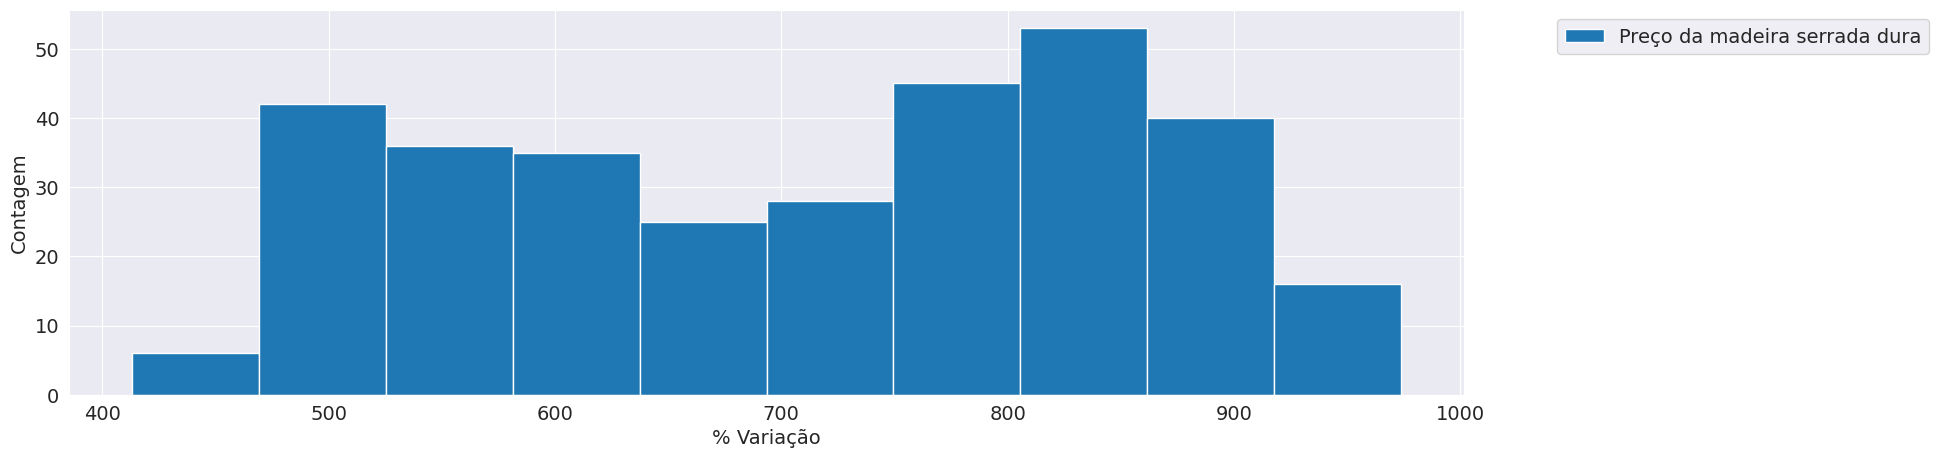

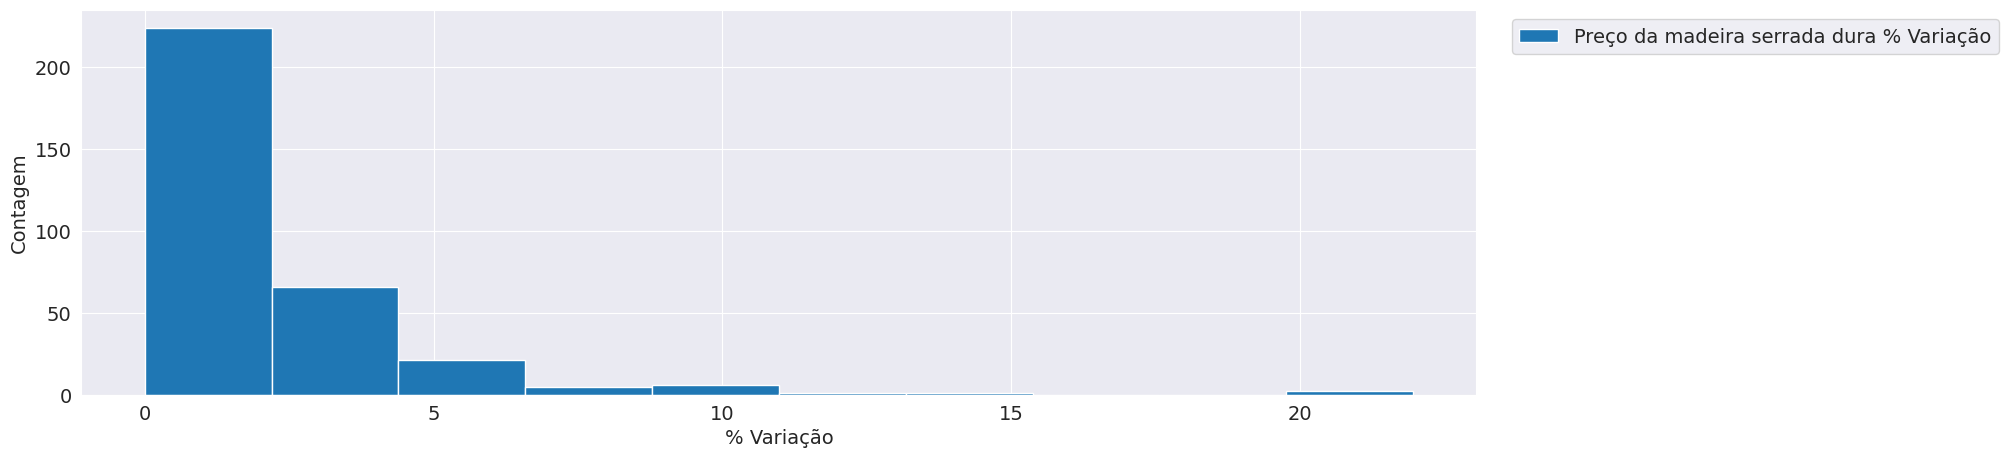

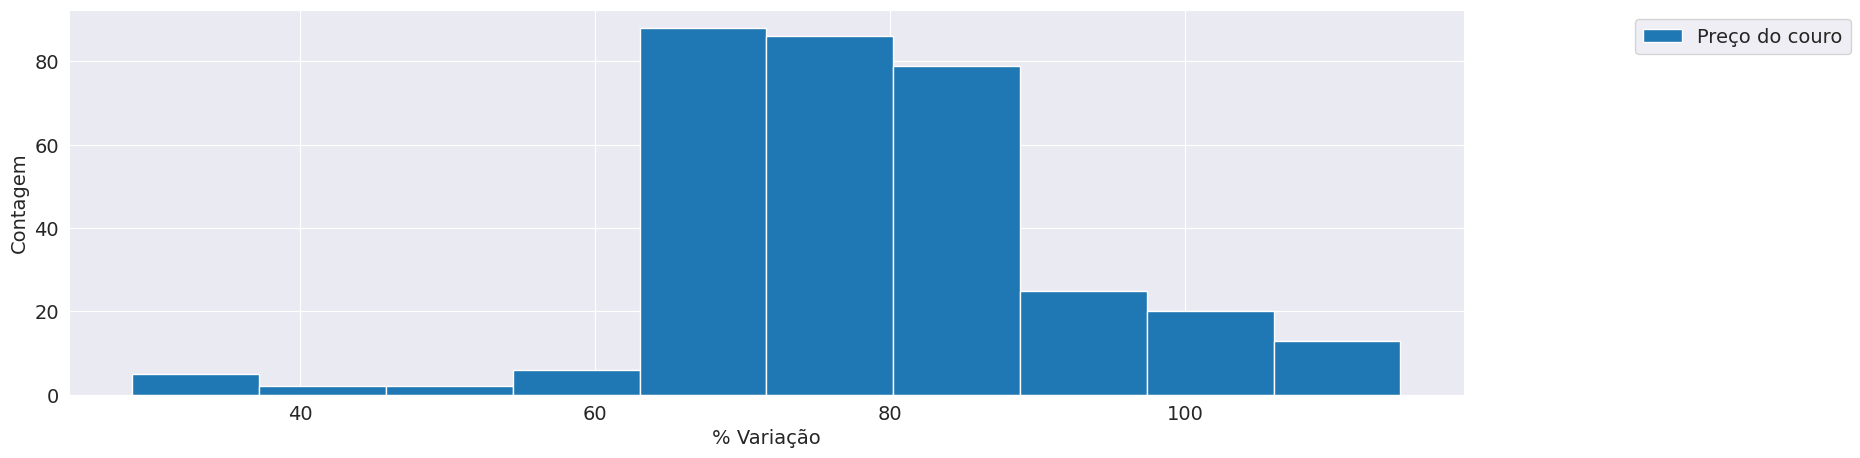

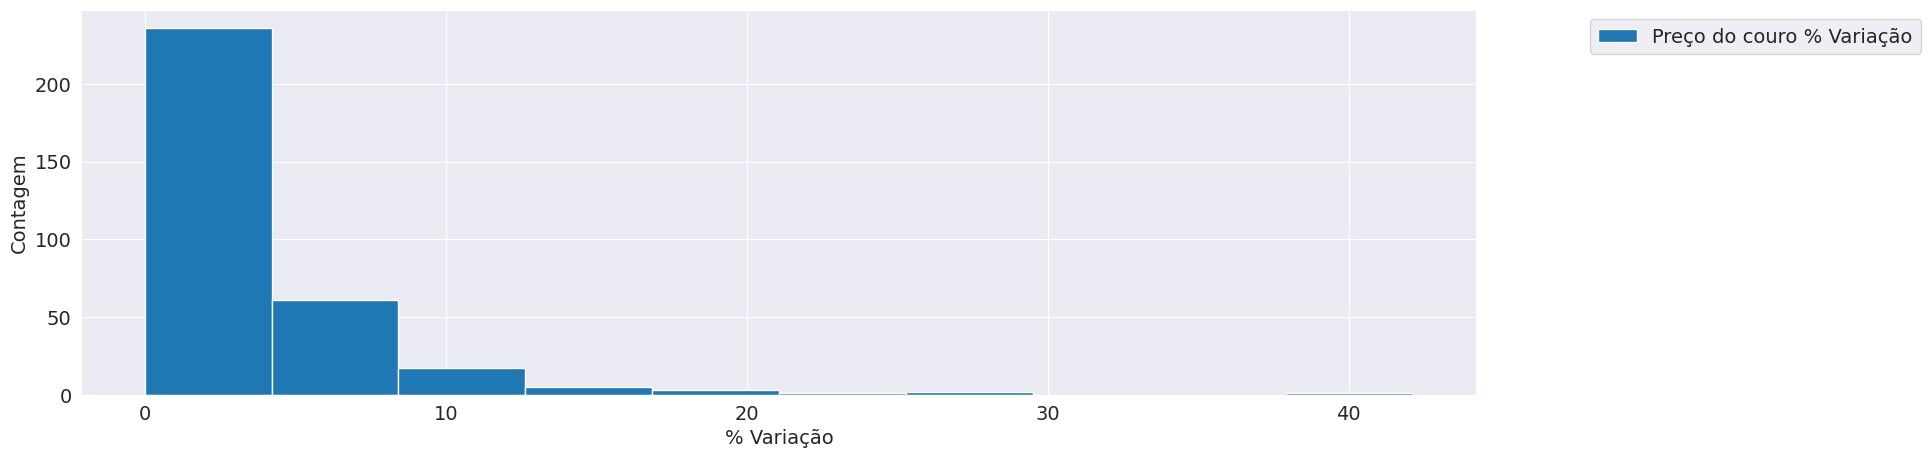

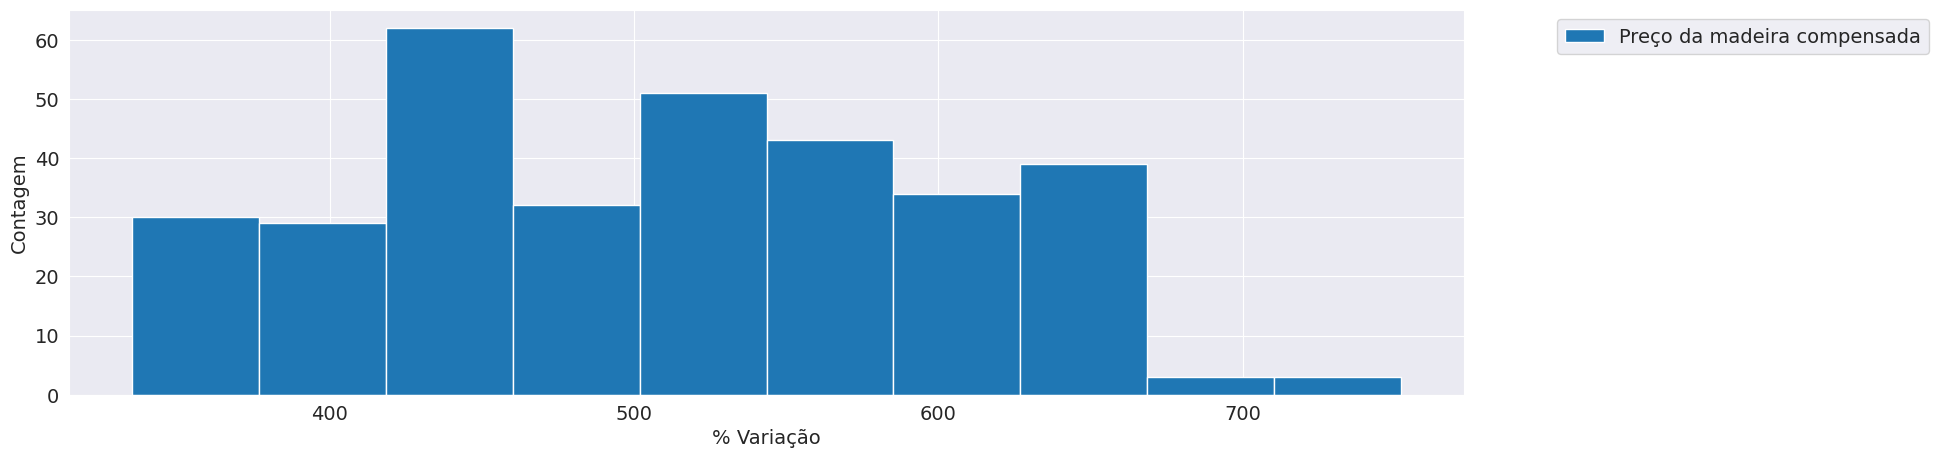

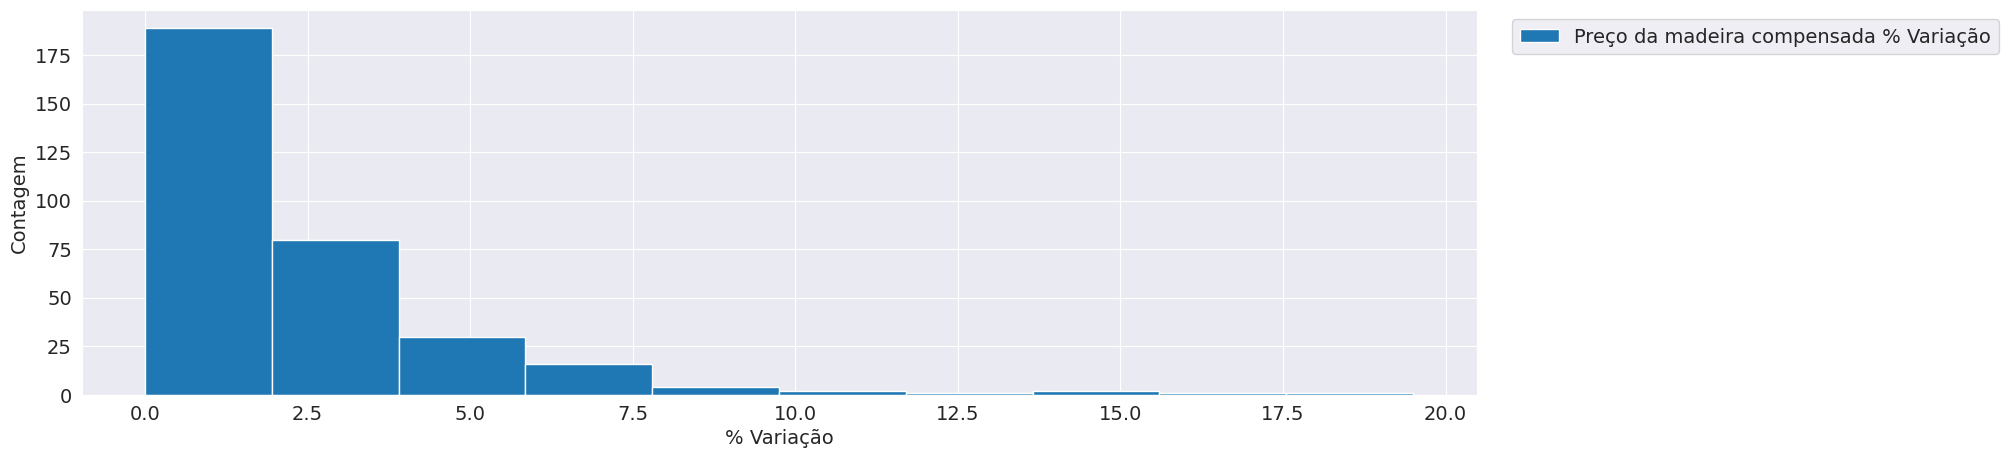

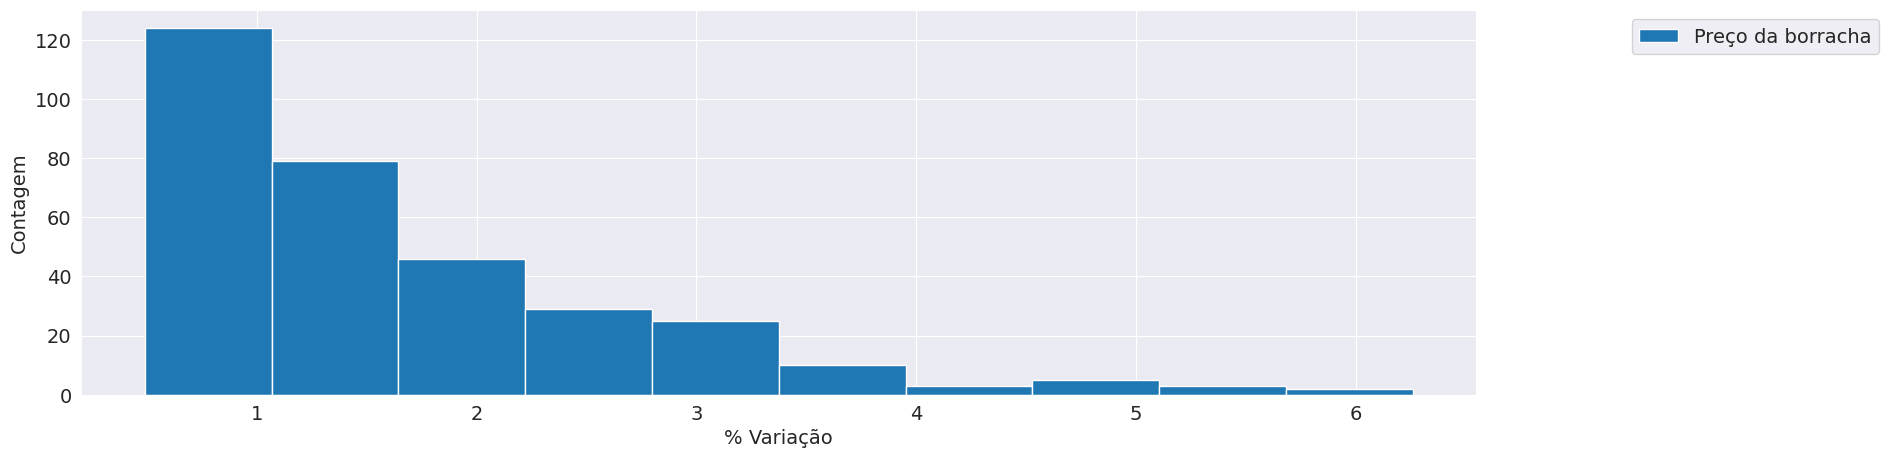

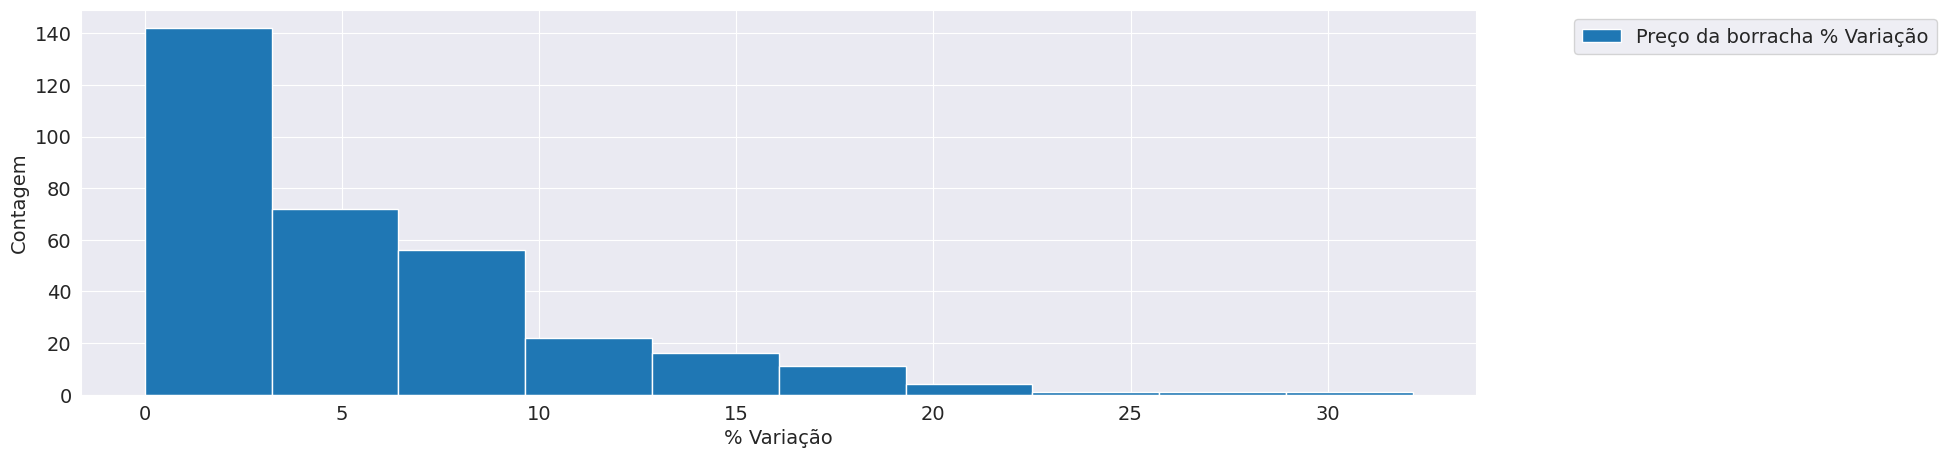

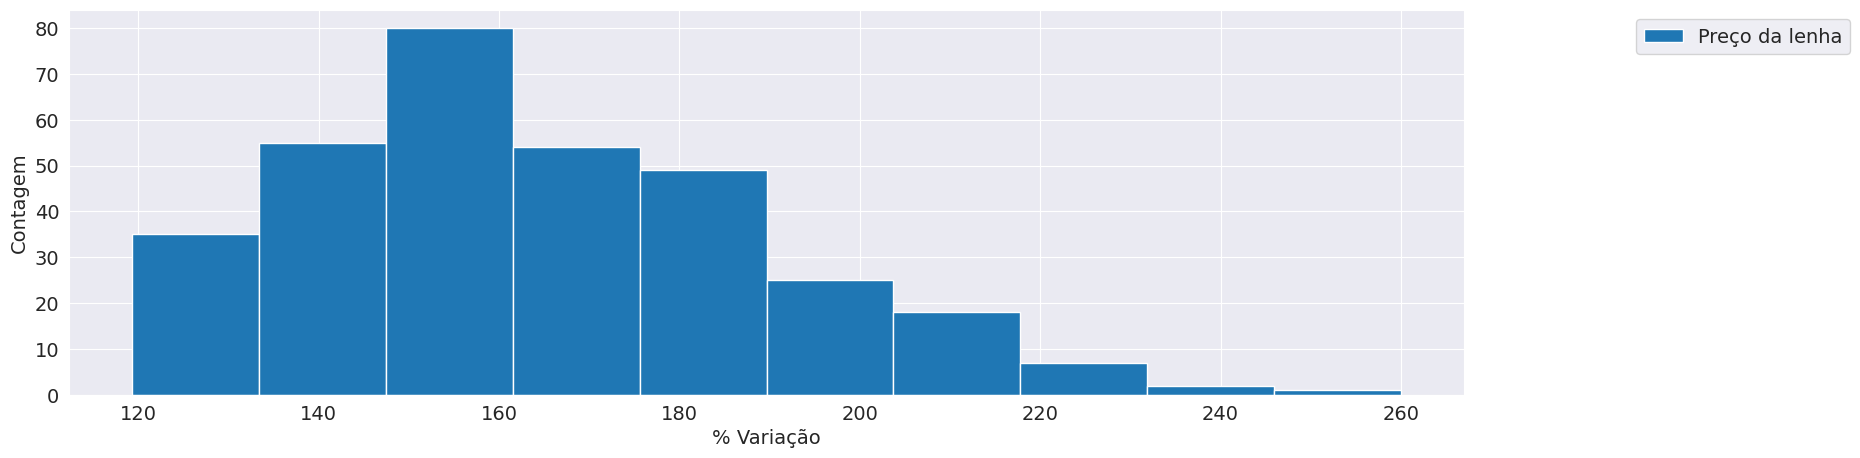

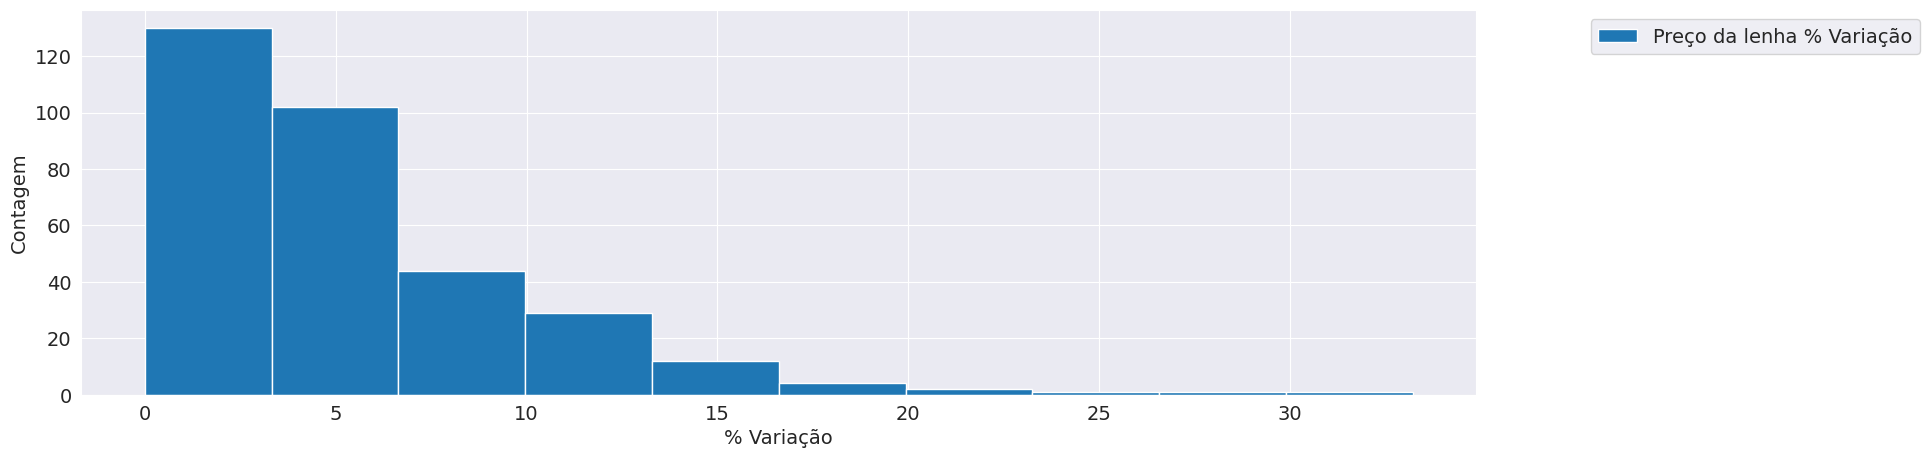

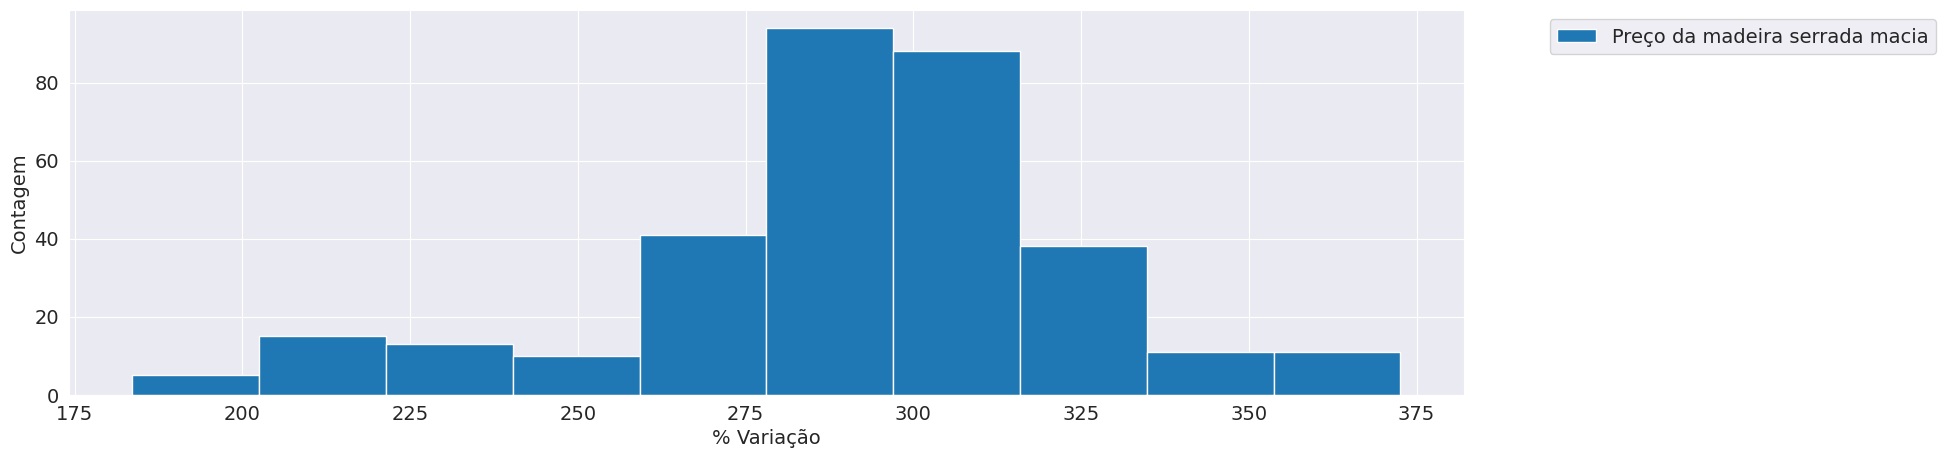

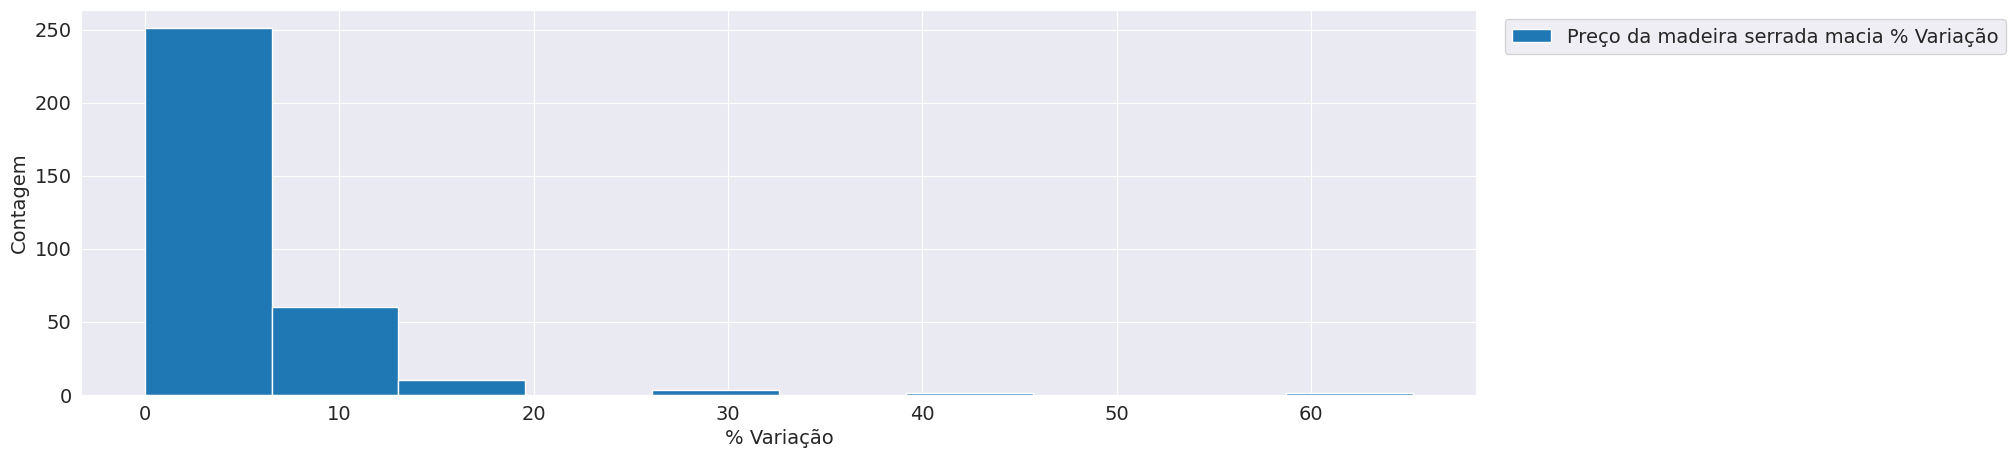

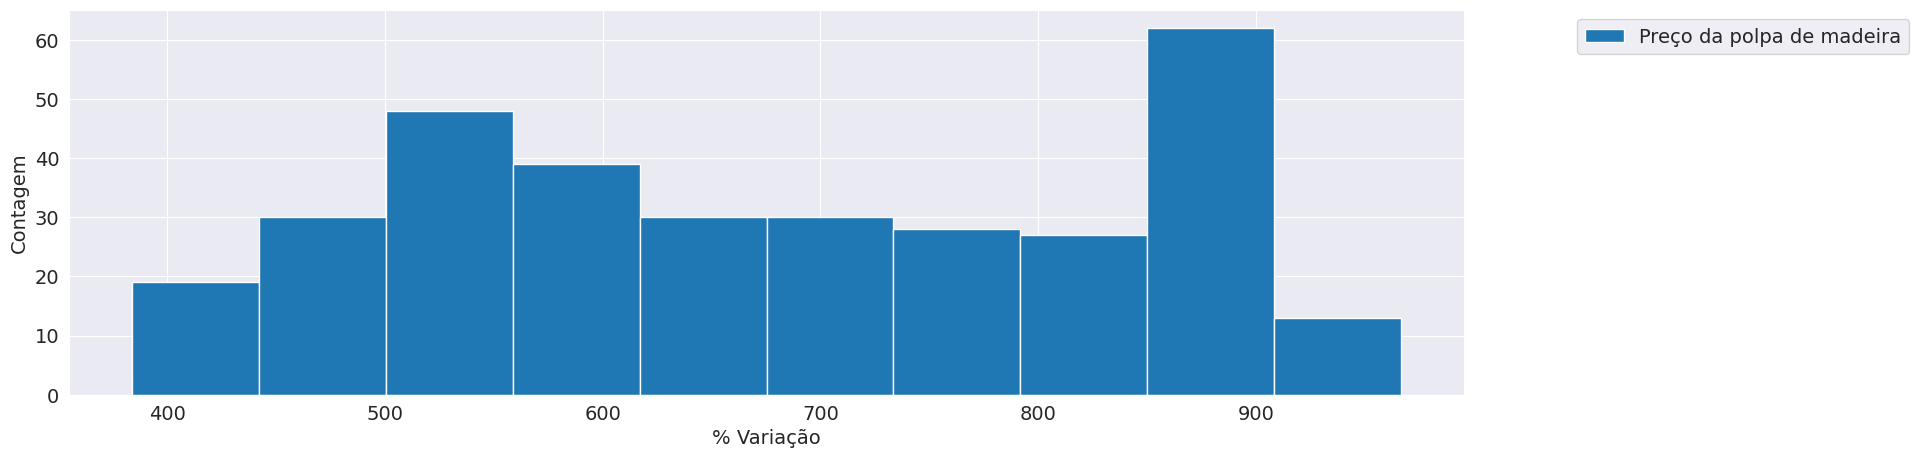

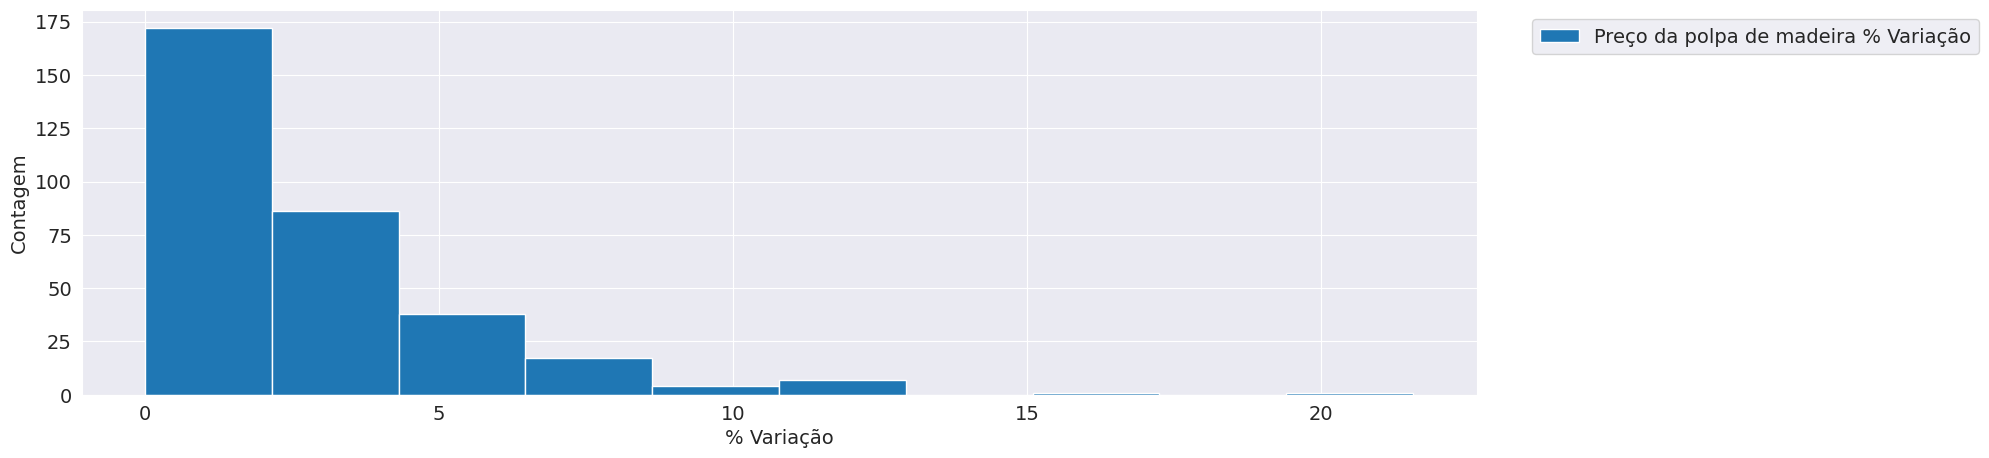

In [24]:
changelist=["Preço da lã grossa", "Preço da lã grossa % Variação", "Preço Copra", "Preço da Copra % Variação", "Preço do algodão", "Preço do algodão % Variação","Preço de lã fina", "Preço de lã fina % Variação",
"Preço da tora dura", "Preço da tora dura % Variação", "Preço da madeira serrada dura", "Preço da madeira serrada dura % Variação", "Preço do couro", "Preço do couro % Variação", "Preço da madeira compensada",
"Preço da madeira compensada % Variação", "Preço da borracha", "Preço da borracha % Variação", "Preço da lenha",  "Preço da lenha % Variação", "Preço da madeira serrada macia", "Preço da madeira serrada macia % Variação",
"Preço da polpa de madeira", "Preço da polpa de madeira % Variação"]
for i in range(len(changelist)):
    plt.figure(figsize=(10,10))
    materiaPrima[changelist[i]].hist(figsize=(18, 5), linewidth=1)
    plt.xlabel('% Variação')
    plt.ylabel('Contagem')
    plt.legend(changelist[i:],loc='upper center',bbox_to_anchor=(1.2,1))

Podemos observar que a maioria das matérias-primas tem % de mudança frequente ideal inferior a 5%

##2) Encontre a matéria-prima que tem o menor preço ao longo dos anos

Text(0.5, 0.98, 'Comparação de preços de matérias-primas')

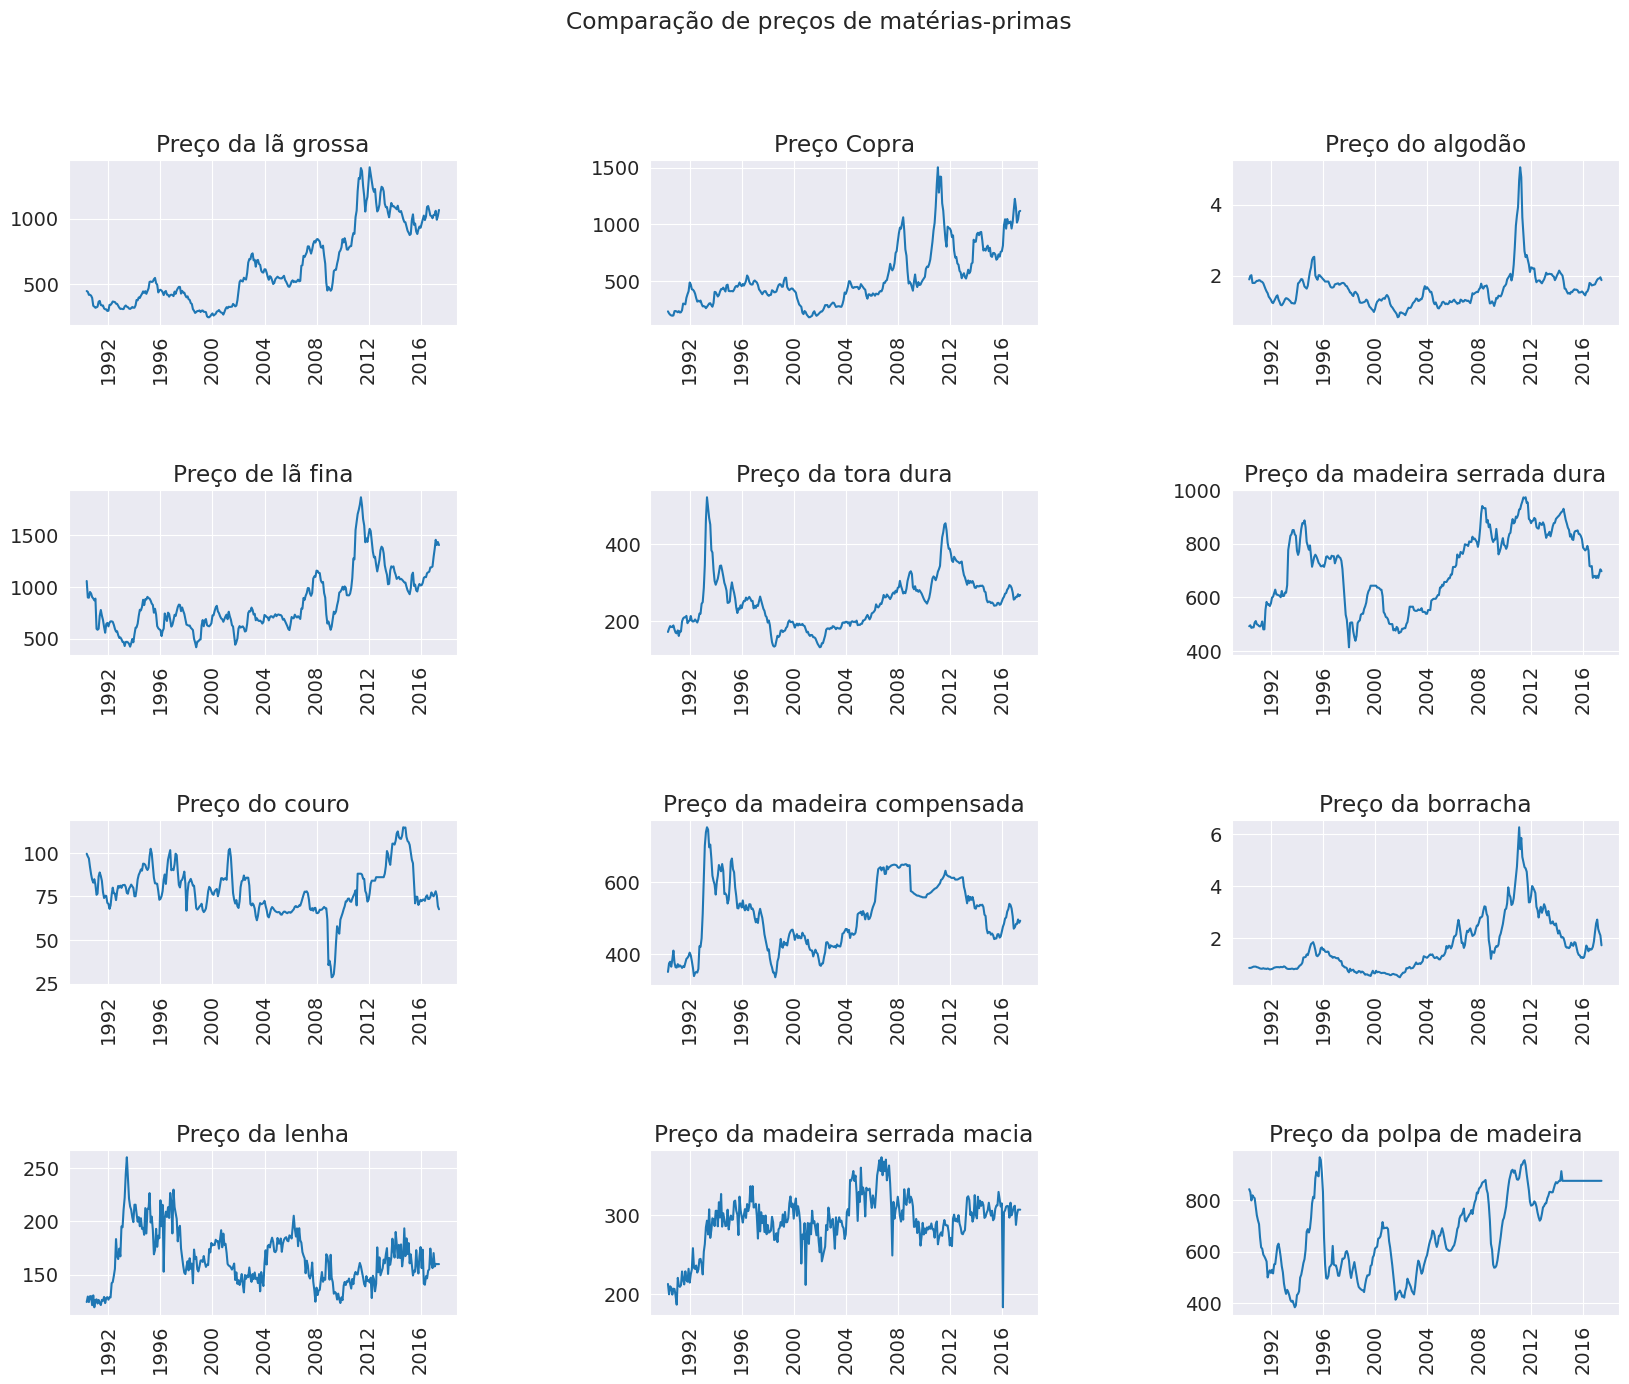

In [25]:
plt.figure(figsize=(20, 15))
materialslist=['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira']
for i in range(len(materialslist)):
    plt.subplot(4,3,i+1)
    plt.subplots_adjust( hspace=1 ,wspace=0.5)
    plt.title(materialslist[i])
    plt.plot(materiaPrima[materialslist[i]])
    plt.xticks(rotation=90)
plt.suptitle("Comparação de preços de matérias-primas")

Podemos ver que o algodão e a borracha são de preços mais baixos vamos comparar preços para entender melhor qual é o mais baixo

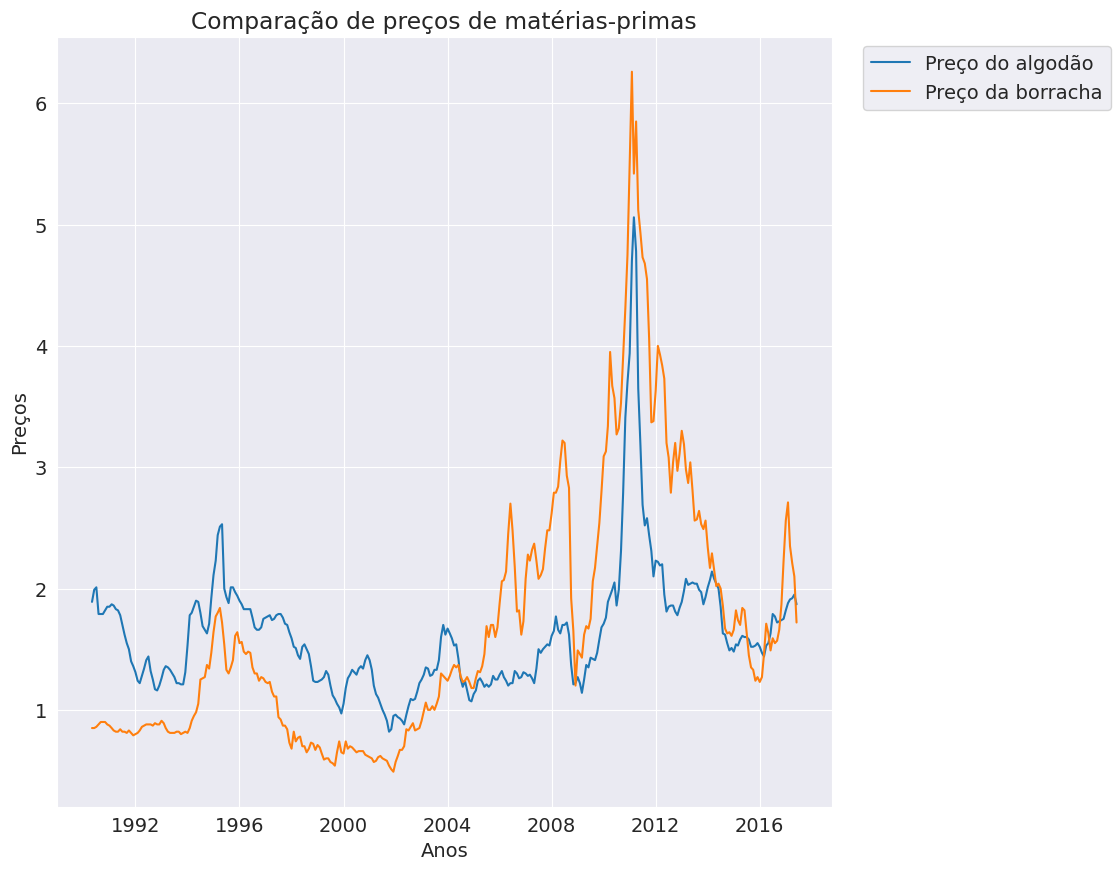

In [26]:
plt.figure(figsize=(10, 10))
plt.plot(materiaPrima[['Preço do algodão', 'Preço da borracha']])
plt.title("Comparação de preços de matérias-primas")
plt.xlabel('Anos')
plt.ylabel('Preços')
plt.legend(['Preço do algodão', 'Preço da borracha'],loc='upper center',bbox_to_anchor=(1.2,1))

algodão é matéria-prima de menor preço nos últimos anos.

Tanto o algodão quanto a borracha são materiais de baixo preço.

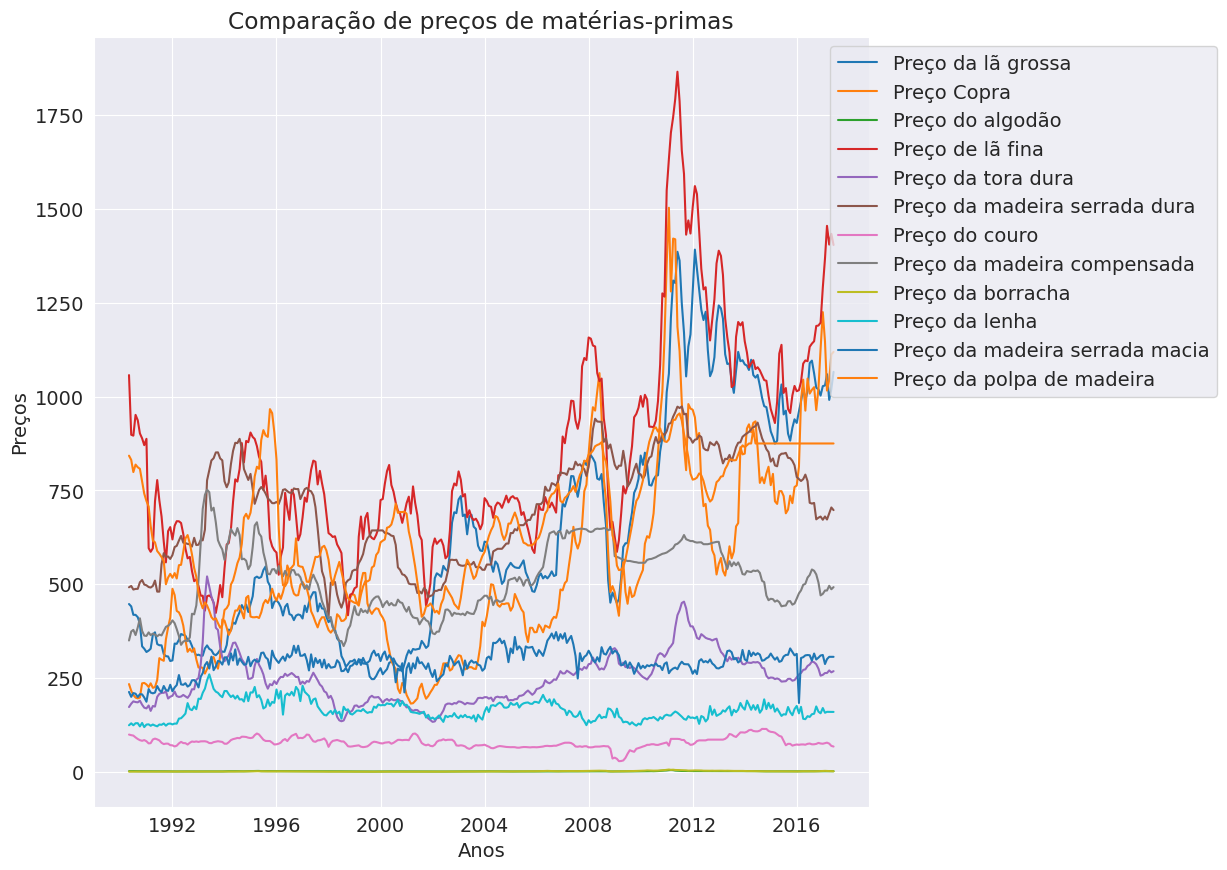

In [27]:
plt.figure(figsize=(10, 10))
plt.plot(materiaPrima[['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira']])
plt.title("Comparação de preços de matérias-primas")
plt.xlabel('Anos')
plt.ylabel('Preços')
plt.legend(['Preço da lã grossa',  'Preço Copra', 'Preço do algodão', 'Preço de lã fina', 'Preço da tora dura', 'Preço da madeira serrada dura', 'Preço do couro', 'Preço da madeira compensada', 'Preço da borracha',
'Preço da lenha', 'Preço da madeira serrada macia', 'Preço da polpa de madeira'],loc='upper center',bbox_to_anchor=(1.2,1))

A partir dos gráficos pudemos analisar as matérias-primas em tipos de acordo com seu preço ao longo dos anos

materiais de baixo preço:

-algodão, couro, lenha, tora dura, madeira serrada macia, borracha

Materiais de alto preço:

-lã grossa, copra, lã fina, madeira serrada dura, polpa de madeira, madeira compensada

##3) qual matéria-prima tem a maior e menor variação de % de preço

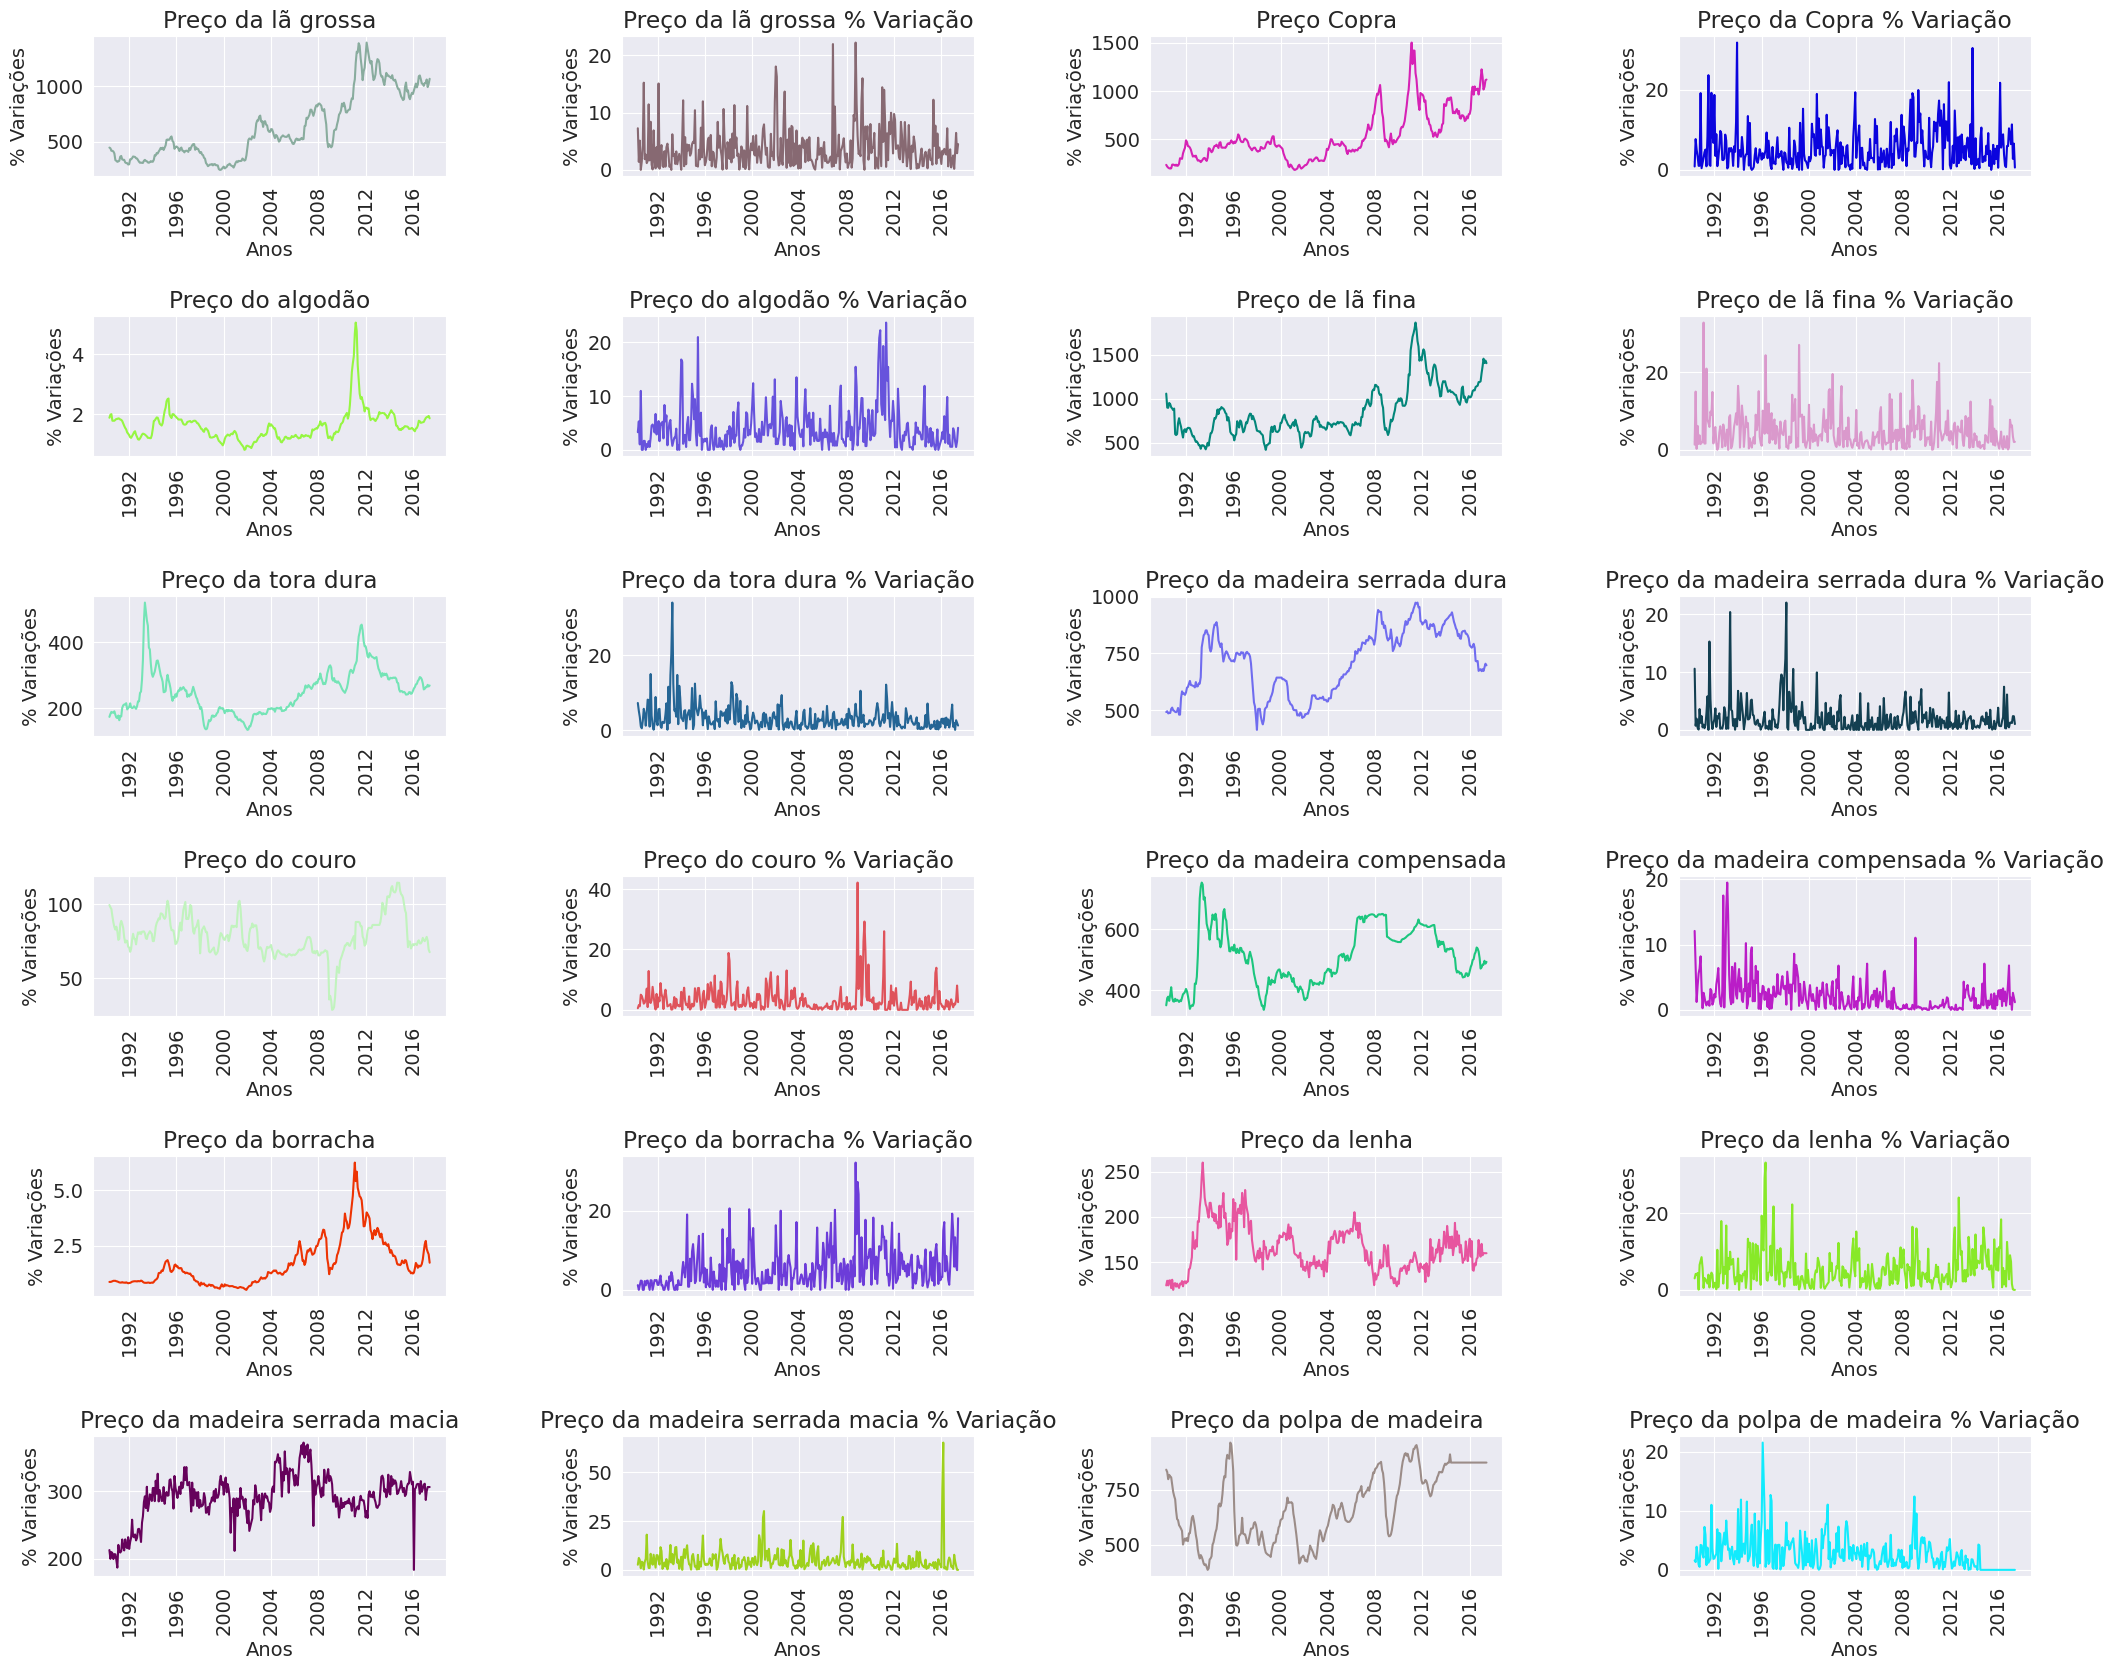

In [28]:
plt.figure(figsize=(25,20))
for i in range(len(changelist)):

    r = random.random()
    b = random.random()
    g = random.random()
    color = (r, g, b)
    plt.subplot(6, 4, i + 1)
    plt.subplots_adjust( hspace=1 ,wspace=0.5)
    plt.plot(materiaPrima[changelist[i]],c=color)
    plt.xticks(rotation=90)
    plt.title(changelist[i])
    plt.xlabel('Anos')
    plt.ylabel('% Variações')

Podemos ver a maior % de mudança em mais de 60 para madeira serrada macia e a menor % de mudança é para madeira compensada em menos de 20%

##4) Encontre as matérias-primas com mudança drástica de preço

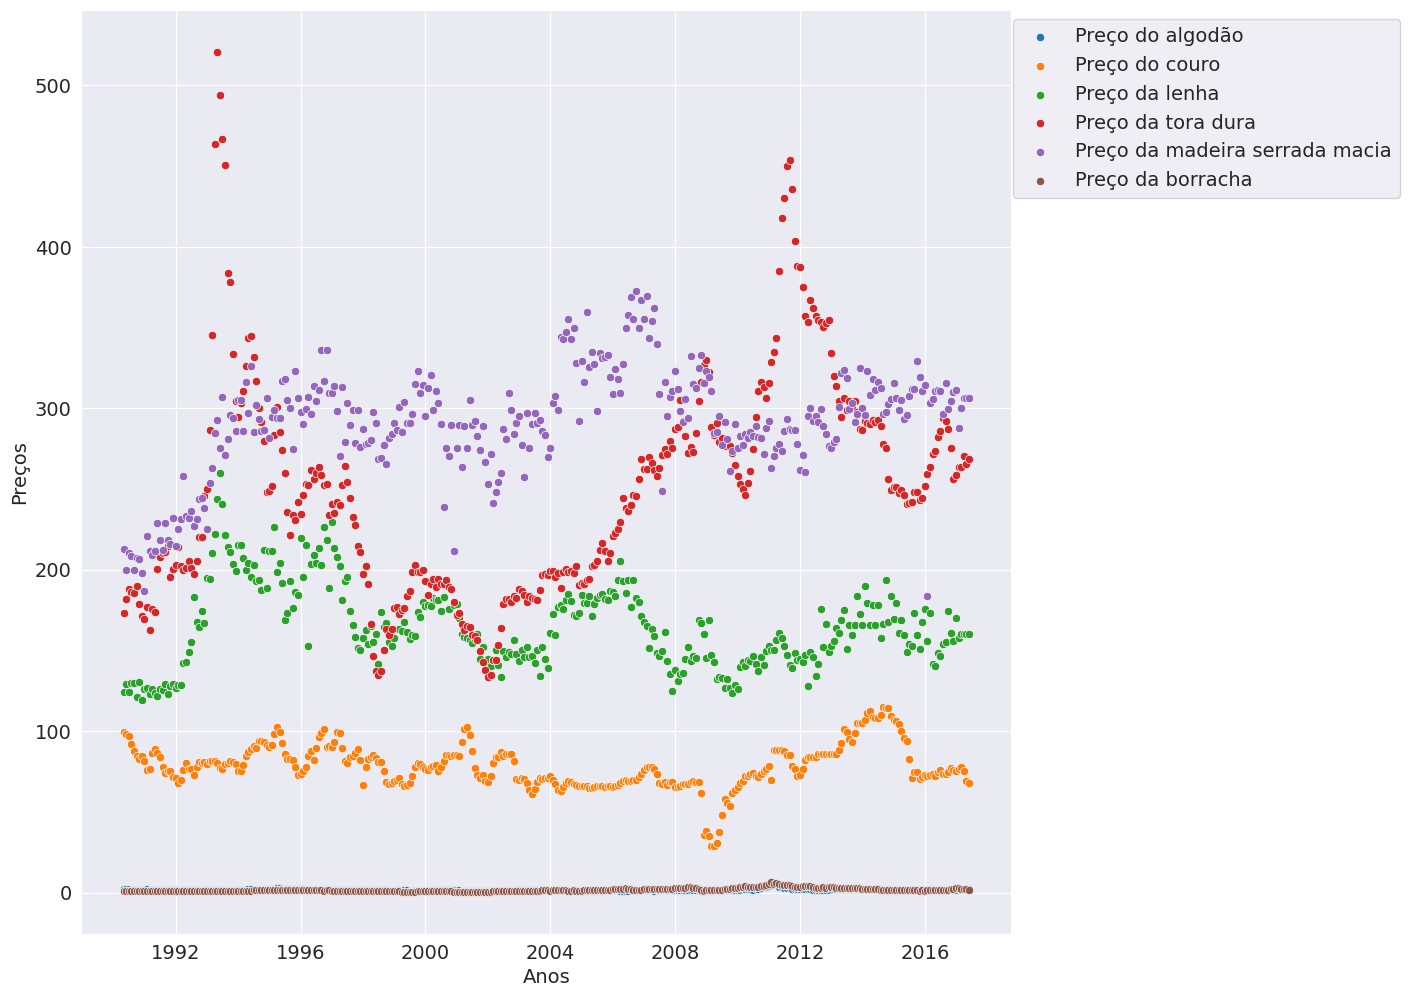

In [29]:
lowlist=['Preço do algodão','Preço do couro','Preço da lenha','Preço da tora dura','Preço da madeira serrada macia','Preço da borracha']
plt.figure(figsize=(12,12))
plt.ylabel('Preços')
plt.xlabel('Anos')
for i in range(len(lowlist)):
    sns.scatterplot(y=materiaPrima[lowlist[i]],x=materiaPrima.index);
    plt.legend(lowlist,loc='upper center',bbox_to_anchor=(1.21,1))

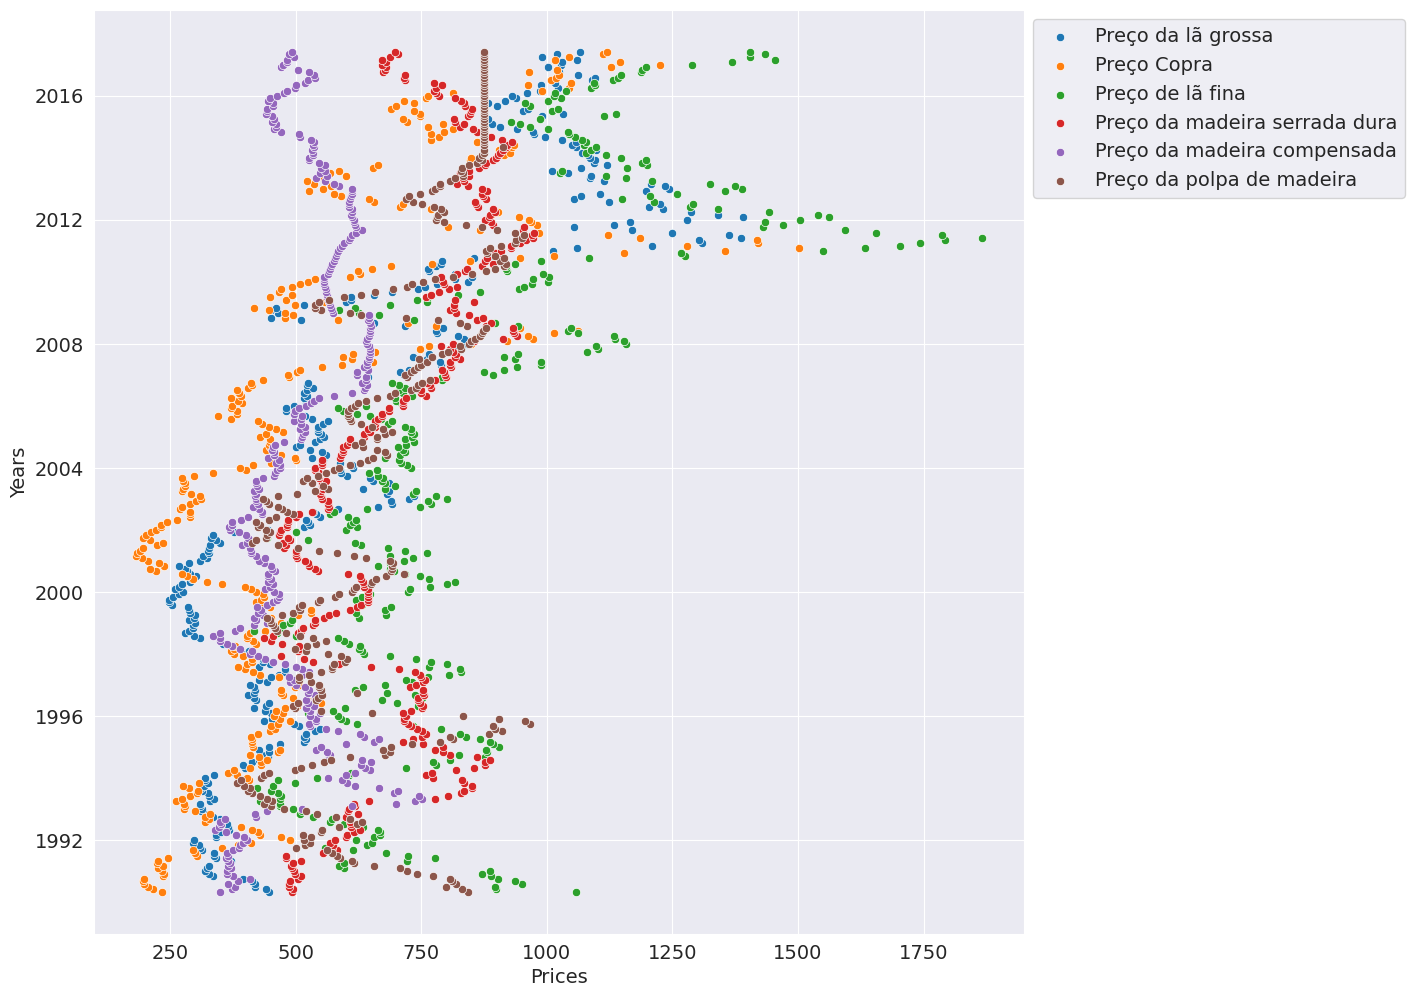

In [30]:
highlist=['Preço da lã grossa', 'Preço Copra', 'Preço de lã fina', 'Preço da madeira serrada dura', 'Preço da madeira compensada', 'Preço da polpa de madeira']
plt.figure(figsize=(12,12))
plt.xlabel('Prices')
plt.ylabel('Years')
for i in range(len(highlist)):
    sns.scatterplot(x=materiaPrima[highlist[i]],y=materiaPrima.index);
    plt.legend(highlist,loc='upper center',bbox_to_anchor=(1.21,1))

A mudança de preço é drástica para o preço de tora dura entre materiais de baixa faixa de preço e entre materiais de alto preço, são os preços de lã fina

##5) Descobrir a faixa de preço de matérias-primas de baixo preço

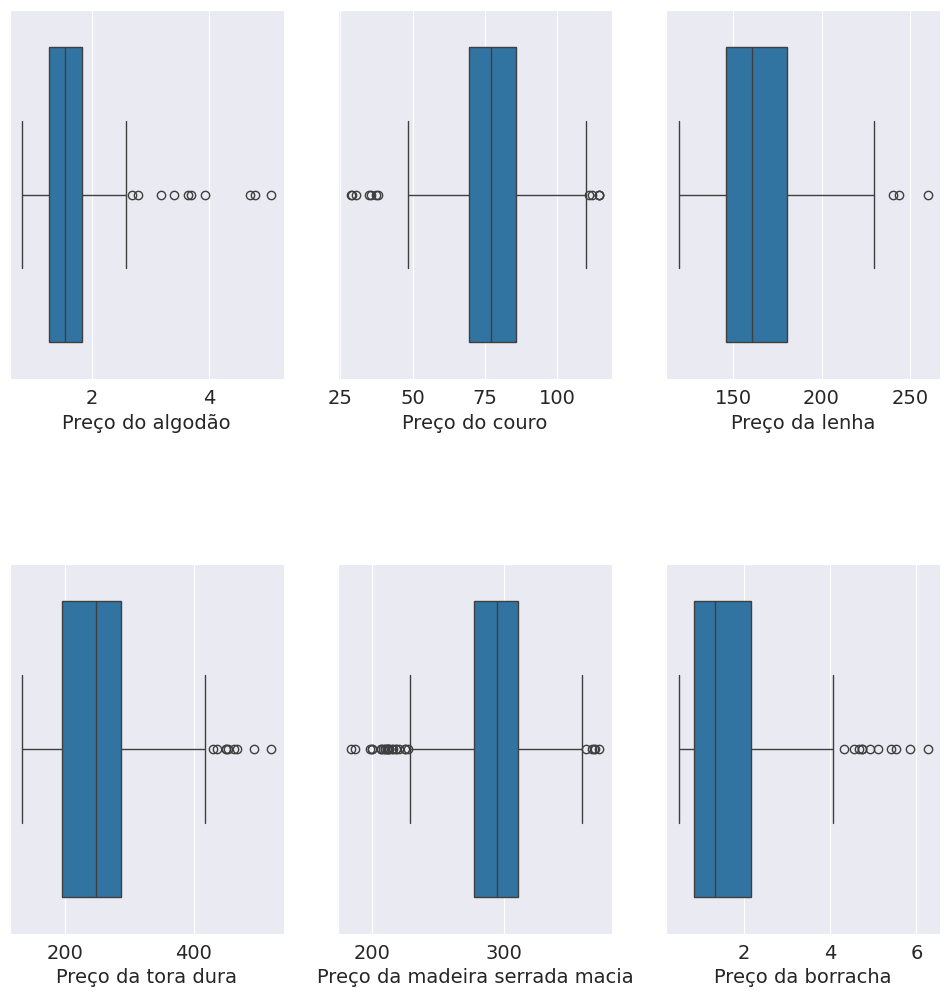

In [31]:
plt.figure(figsize=(12,12))
lowlist=['Preço do algodão','Preço do couro','Preço da lenha','Preço da tora dura','Preço da madeira serrada macia','Preço da borracha']
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.subplots_adjust( hspace=0.5 )
    sns.boxplot(x=materiaPrima[lowlist[i]])

Inclui: O intervalo interquartil está entre Q3 e Q1 mínimo, primeiro quartil (Q1), mediana, terceiro quartil (Q3) e máximo e outliers

##Conclusão
Descobrimos as matérias-primas de alta e baixa gama de acordo com seus preços.

Alta e baixa % de variação dos materiais.

Pudemos identificar a variação de preços ao longo dos anos.

Correlação entre eles usando um mapa de calor.